# Final project notebook: earnings calls and CRSP daily returns

This notebook builds a **daily security–date panel**: CRSP daily fields merged with **prior-quarter** transcript-based metrics, then models **next-day `dlyretx`** (with `next_day_return` from `dlyret` kept for diagnostics) using **LightGBM**, **XGBoost**, optional **Random Forest**, and **walk-forward time-series CV** for hyperparameter tuning.

## How to run

Run cells **top to bottom** in order. The first code cell imports `pandas`; paths point to `Data\Raw Data\` under this project (adjust if your layout differs). Later cells may use **GPU** flags for XGBoost or LightGBM where configured.

## Main outputs

- Cleaned transcript universe aligned with CRSP tickers
- `merged_daily_df` / `model_df` with transcript **missingness flags**, **z-scored** transcript metrics and dynamics (train-fitted scaler), **`dlyret` / `dlyretx` lags**, rolling stats, **OHLC microstructure**, optional **cross-sectional** features, **`FE_STAGE`** ablation switch, and native categorical identifiers (`ticker`, `siccd`, `naics`)
- Time-based train / validation / test split and model comparison metrics



In [1]:
# --- Setup: core imports ---
import pandas as pd 

## 1. Data loading

- Load CRSP daily (`crsp_v2_2014_2024.csv`) and the wide transcript metrics file.
- Use `DataFrame.info()` to confirm dtypes, row counts, and column names before cleaning.



In [2]:
# --- Load raw CRSP and transcript CSVs; print schema ---
crsp_df = pd.read_csv(r"H:\My Drive\Project\FA Project\Data\Raw Data\crsp_v2_2014_2024.csv",low_memory=False)
transcripts_df = pd.read_csv(r"H:\My Drive\Project\FA Project\Data\Raw Data\Transcripts Machine Readable Data.csv",low_memory=False)
print(crsp_df.info())
print(transcripts_df.info() )

<class 'pandas.DataFrame'>
RangeIndex: 495987 entries, 0 to 495986
Data columns (total 27 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   permno        495987 non-null  int64  
 1   permco        495987 non-null  int64  
 2   ticker        495987 non-null  str    
 3   cusip         495987 non-null  str    
 4   issuernm      495987 non-null  str    
 5   siccd         495987 non-null  int64  
 6   naics         495987 non-null  int64  
 7   dlycaldt      495987 non-null  str    
 8   dlyclose      495710 non-null  float64
 9   dlyopen       495710 non-null  float64
 10  dlyhigh       495710 non-null  float64
 11  dlylow        495710 non-null  float64
 12  dlyprc        495986 non-null  float64
 13  dlyret        495984 non-null  float64
 14  dlyretx       495984 non-null  float64
 15  dlyvol        495986 non-null  float64
 16  shrout        495987 non-null  int64  
 17  dlycap        495986 non-null  float64
 18  dlycumfacpr   4

## 2. Ticker coverage (transcripts vs CRSP)

Identify symbols that appear in **transcripts** but not in **CRSP**, and decide how to restrict the transcript universe so merges are reliable.



### Tickers in transcripts missing from CRSP

List symbols present in the transcript file but **not** in CRSP `ticker`, before we restrict the transcript universe.


In [3]:
# --- Compare unique tickers: transcripts vs CRSP ---
crsp_tickers = crsp_df['ticker'].unique()
transcripts_tickers = transcripts_df['Symbol'].unique()
print(transcripts_df['Symbol'].nunique(),"---",crsp_df['ticker'].nunique())
for ticker in transcripts_tickers:
    if ticker not in crsp_tickers:
        print(ticker, transcripts_df[transcripts_df['Symbol'] == ticker]['Company Name'].unique())



193 --- 185
BF.B <ArrowStringArray>
['Brown-Forman']
Length: 1, dtype: str
SLB <ArrowStringArray>
['Schlumberger']
Length: 1, dtype: str
AON <ArrowStringArray>
['Aon plc']
Length: 1, dtype: str
BRK.B <ArrowStringArray>
['Berkshire Hathaway']
Length: 1, dtype: str
IVZ <ArrowStringArray>
['Invesco']
Length: 1, dtype: str
ETN <ArrowStringArray>
['Eaton Corporation']
Length: 1, dtype: str
ACN <ArrowStringArray>
['Accenture']
Length: 1, dtype: str
EQR <ArrowStringArray>
['Equity Residential']
Length: 1, dtype: str


### Tickers dropped from transcripts

The previous cell lists companies present in **transcripts** but not in **CRSP** (e.g. alternate share classes). Those tickers are removed from the transcript table so later merges use a consistent symbol set.


## 3. Exploratory missingness

Quick **null counts** on the raw CRSP and transcript tables after the initial universe decision.



In [4]:
# --- CRSP: null counts per column ---
crsp_df.isnull().sum()

permno            0
permco            0
ticker            0
cusip             0
issuernm          0
siccd             0
naics             0
dlycaldt          0
dlyclose        277
dlyopen         277
dlyhigh         277
dlylow          277
dlyprc            1
dlyret            3
dlyretx           3
dlyvol            1
shrout            0
dlycap            1
dlycumfacpr       0
dlycumfacshr      0
sprtrn            0
vwretd            0
ewretd            0
securitytype      0
sharetype         0
usincflg          0
shradrflg         0
dtype: int64

In [5]:
# --- Transcripts: null counts per column ---
transcripts_df.isnull().sum()

Symbol            0
Company Name      0
Metrics           0
CQ12014          20
CQ22014          24
CQ32014          32
CQ42014          28
CQ12015          20
CQ22015          40
CQ32015          32
CQ42015          28
CQ12016          32
CQ22016          32
CQ32016          36
CQ42016          44
CQ12017          24
CQ22017          24
CQ32017          24
CQ42017          24
CQ12018          28
CQ22018          28
CQ32018          28
CQ42018          28
CQ12019          24
CQ22019          28
CQ32019          32
CQ42019          24
CQ12020          33
CQ22020          32
CQ32020          20
CQ42020          28
CQ12021          20
CQ22021          28
CQ32021          20
CQ42021          24
CQ12022          28
CQ22022          28
CQ32022          24
CQ42022          20
CQ12023          20
CQ22023          20
CQ32023          20
CQ42023          20
CQ12024          16
CQ22024          20
CQ32024          24
CQ42024          16
Unnamed: 47     772
dtype: int64

## 4. Transcript filtering and quarterly missingness

Keep transcript rows in the CRSP ticker set, analyze **quarterly (CQ*)** missing values by ticker, optionally drop the worst tickers, and summarize missing rates.



In [6]:
# 1) Filter transcript rows for symbols absent from CRSP
crsp_tickers = set(crsp_df['ticker'].dropna().unique())
transcript_tickers = set(transcripts_df['Symbol'].dropna().unique())
missing_symbols = sorted(transcript_tickers - crsp_tickers)

print("Symbols in transcripts but not in CRSP:", missing_symbols)
print("Count:", len(missing_symbols))

transcripts_filtered_df = transcripts_df[~transcripts_df['Symbol'].isin(missing_symbols)].copy()

# Drop unnamed columns if present
transcripts_filtered_df = transcripts_filtered_df.loc[
    :, ~transcripts_filtered_df.columns.str.contains(r'^Unnamed')
]

print("Unique symbols before:", transcripts_df['Symbol'].nunique())
print("Unique symbols after:", transcripts_filtered_df['Symbol'].nunique())
print("Rows before:", len(transcripts_df), "| Rows after:", len(transcripts_filtered_df))

Symbols in transcripts but not in CRSP: ['ACN', 'AON', 'BF.B', 'BRK.B', 'EQR', 'ETN', 'IVZ', 'SLB']
Count: 8
Unique symbols before: 193
Unique symbols after: 185
Rows before: 772 | Rows after: 740


In [7]:
# 2) Identify which tickers have missing values in OHLC columns
ohlc_cols = ['dlyclose', 'dlyhigh', 'dlyopen', 'dlylow']
missing_ohlc_mask = crsp_df[ohlc_cols].isna().any(axis=1)

missing_ohlc_ticker_counts = crsp_df.loc[missing_ohlc_mask, 'ticker'].value_counts()
print("Ticker-level missing OHLC counts:")
print(missing_ohlc_ticker_counts)

missing_ohlc_details = crsp_df.loc[
    missing_ohlc_mask,
    ['permno', 'ticker', 'dlycaldt'] + ohlc_cols
].sort_values(['ticker', 'dlycaldt'])

print("\nSample missing OHLC rows:")
print(missing_ohlc_details.head(20))

Ticker-level missing OHLC counts:
ticker
MKC     275
BIIB      2
Name: count, dtype: int64

Sample missing OHLC rows:
        permno ticker    dlycaldt  dlyclose  dlyhigh  dlyopen  dlylow
361463   76841   BIIB  2020-11-06       NaN      NaN      NaN     NaN
362113   76841   BIIB  2023-06-09       NaN      NaN      NaN     NaN
461080   89155    MKC  2014-01-10       NaN      NaN      NaN     NaN
461089   89155    MKC  2014-01-24       NaN      NaN      NaN     NaN
461090   89155    MKC  2014-01-27       NaN      NaN      NaN     NaN
461097   89155    MKC  2014-02-05       NaN      NaN      NaN     NaN
461103   89155    MKC  2014-02-13       NaN      NaN      NaN     NaN
461107   89155    MKC  2014-02-20       NaN      NaN      NaN     NaN
461110   89155    MKC  2014-02-25       NaN      NaN      NaN     NaN
461113   89155    MKC  2014-02-28       NaN      NaN      NaN     NaN
461115   89155    MKC  2014-03-04       NaN      NaN      NaN     NaN
461125   89155    MKC  2014-03-18       Na

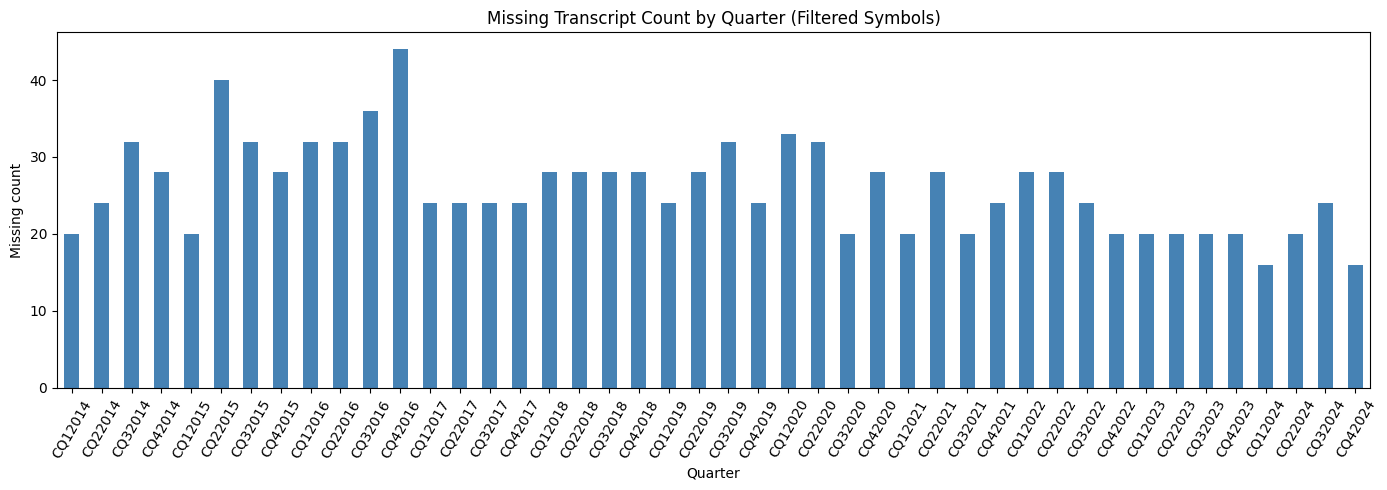

In [8]:
# 3) Plot missing count by quarter in transcripts (filtered universe)
import re
import matplotlib.pyplot as plt

quarter_cols = [
    c for c in transcripts_filtered_df.columns
    if re.match(r'^CQ[1-4]\d{4}$', c)
]

def quarter_sort_key(col_name: str):
    """Sort key for transcript quarter columns named CQ{n}{yyyy}.

    Returns a (year, quarter) tuple so chronological sorting matches calendar order.
    """
    q = int(col_name[2])
    y = int(col_name[3:])
    return (y, q)

quarter_cols = sorted(quarter_cols, key=quarter_sort_key)
missing_per_quarter = transcripts_filtered_df[quarter_cols].isna().sum()

plt.figure(figsize=(14, 5))
missing_per_quarter.plot(kind='bar', color='steelblue')
plt.title('Missing Transcript Count by Quarter (Filtered Symbols)')
plt.xlabel('Quarter')
plt.ylabel('Missing count')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


Top 10 tickers by missing quarterly transcript values:
        n_rows  missing_cells  total_quarterly_cells  missing_rate
Symbol                                                            
COR          4            176                    176      1.000000
EXPD         4            176                    176      1.000000
SCHW         4            176                    176      1.000000
CVX          4            176                    176      1.000000
TROW         4            148                    176      0.840909
MKC          4             48                    176      0.272727
CTAS         4             44                    176      0.250000
HUM          4             28                    176      0.159091
WMT          4             20                    176      0.113636
MU           4             16                    176      0.090909
COST         4             16                    176      0.090909
CI           4             16                    176      0.090909
AVGO   

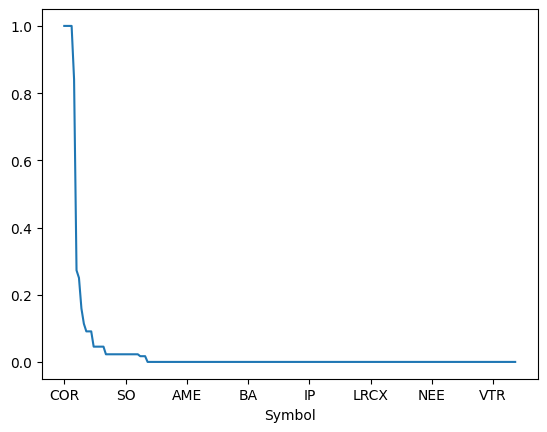

In [9]:
# 4) Ticker with highest transcript missing values vs total quarterly cells
symbol_rows = transcripts_filtered_df.groupby('Symbol').size().rename('n_rows')
missing_cells = transcripts_filtered_df.groupby('Symbol')[quarter_cols].apply(
    lambda x: x.isna().sum().sum()
).rename('missing_cells')

ticker_missing_summary = pd.concat([symbol_rows, missing_cells], axis=1)
ticker_missing_summary['total_quarterly_cells'] = ticker_missing_summary['n_rows'] * len(quarter_cols)
ticker_missing_summary['missing_rate'] = (
    ticker_missing_summary['missing_cells'] / ticker_missing_summary['total_quarterly_cells']
)

ticker_missing_summary = ticker_missing_summary.sort_values(
    by='missing_cells', ascending=False
)

print('Top 10 tickers by missing quarterly transcript values:')
print(ticker_missing_summary.head(20))

ticker_missing_summary['missing_rate'].plot(kind="line")
plt.show()

### Tickers with heavy quarterly missingness

Some tickers had **entirely** or **mostly** missing `CQ*` transcript fields. The following cells **drop rows** for the top four tickers by missing quarterly cells, then re-check missing counts.


In [10]:
# 5) Remove rows for the top 4 tickers with the most missing quarterly transcript values
# Requires: transcripts_filtered_df, ticker_missing_summary (sorted by missing_cells desc)
top4_missing_tickers = ticker_missing_summary.head(4).index.tolist()
print('Dropping rows for top 4 missing tickers:', top4_missing_tickers)

rows_before = len(transcripts_filtered_df)
syms_before = transcripts_filtered_df['Symbol'].nunique()

transcripts_filtered_df = transcripts_filtered_df[
    ~transcripts_filtered_df['Symbol'].isin(top4_missing_tickers)
].copy()

print('Rows before drop:', rows_before, '| after:', len(transcripts_filtered_df))
print('Unique symbols before/after:', syms_before, '|', transcripts_filtered_df['Symbol'].nunique())


Dropping rows for top 4 missing tickers: ['COR', 'EXPD', 'SCHW', 'CVX']
Rows before drop: 740 | after: 724
Unique symbols before/after: 185 | 181


New missing values per quarter after deletion:
CQ12014     4
CQ22014     8
CQ32014    16
CQ42014    12
CQ12015     4
CQ22015    24
CQ32015    16
CQ42015    12
CQ12016    16
CQ22016    16
CQ32016    20
CQ42016    28
CQ12017     8
CQ22017     8
CQ32017     8
CQ42017     8
CQ12018    12
CQ22018    12
CQ32018    12
CQ42018    12
CQ12019     8
CQ22019    12
CQ32019    16
CQ42019     8
CQ12020    17
CQ22020    16
CQ32020     4
CQ42020    12
CQ12021     4
CQ22021    12
CQ32021     4
CQ42021     8
CQ12022    12
CQ22022    12
CQ32022     8
CQ42022     4
CQ12023     4
CQ22023     4
CQ32023     4
CQ42023     4
CQ12024     0
CQ22024     4
CQ32024     8
CQ42024     0
dtype: int64

Total missing quarterly values after deletion: 441


<Axes: >

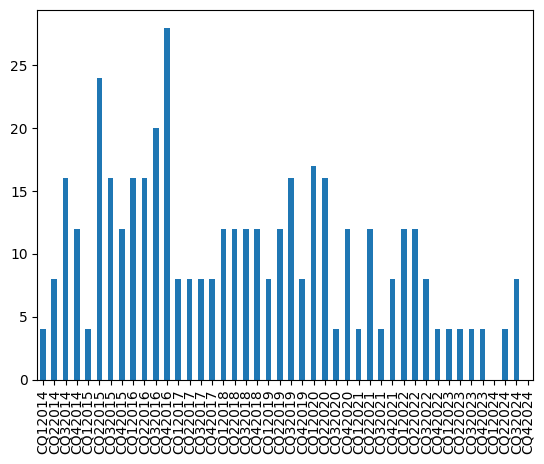

In [11]:
# 6) New missing values after deleting top 4 missing tickers
new_missing_per_quarter = transcripts_filtered_df[quarter_cols].isna().sum()
print('New missing values per quarter after deletion:')
print(new_missing_per_quarter)
print('\nTotal missing quarterly values after deletion:', int(new_missing_per_quarter.sum()))
new_missing_per_quarter.plot(kind="bar")

### After dropping high-missing transcript rows

Quarterly missing counts and a bar chart summarize remaining gaps after removing the worst tickers by missing `CQ*` cells.


In [12]:
# 7) Average and median missing rate across quarters in transcripts_df
# If you want this on the original dataframe, use transcripts_df;
# if you want post-cleaning values, replace with transcripts_filtered_df.
quarter_cols_all = [c for c in transcripts_df.columns if c.startswith('CQ')]

quarter_missing_rate = transcripts_df[quarter_cols_all].isna().mean() * 100  # in %

print('Missing rate (%) of each quarter:')
print(quarter_missing_rate)

avg_missing_rate = quarter_missing_rate.mean()
median_missing_rate = quarter_missing_rate.median()

print(f"\nAverage missing rate across quarters: {avg_missing_rate:.2f}%")
print(f"Median missing rate across quarters: {median_missing_rate:.2f}%")

Missing rate (%) of each quarter:
CQ12014    2.590674
CQ22014    3.108808
CQ32014    4.145078
CQ42014    3.626943
CQ12015    2.590674
CQ22015    5.181347
CQ32015    4.145078
CQ42015    3.626943
CQ12016    4.145078
CQ22016    4.145078
CQ32016    4.663212
CQ42016    5.699482
CQ12017    3.108808
CQ22017    3.108808
CQ32017    3.108808
CQ42017    3.108808
CQ12018    3.626943
CQ22018    3.626943
CQ32018    3.626943
CQ42018    3.626943
CQ12019    3.108808
CQ22019    3.626943
CQ32019    4.145078
CQ42019    3.108808
CQ12020    4.274611
CQ22020    4.145078
CQ32020    2.590674
CQ42020    3.626943
CQ12021    2.590674
CQ22021    3.626943
CQ32021    2.590674
CQ42021    3.108808
CQ12022    3.626943
CQ22022    3.626943
CQ32022    3.108808
CQ42022    2.590674
CQ12023    2.590674
CQ22023    2.590674
CQ32023    2.590674
CQ42023    2.590674
CQ12024    2.072539
CQ22024    2.590674
CQ32024    3.108808
CQ42024    2.072539
dtype: float64

Average missing rate across quarters: 3.37%
Median missing rate across

## 5. CRSP universe alignment and column prep

Drop tickers removed from transcripts, inspect CRSP uniqueness, **drop unused columns**, and parse **`dlycaldt`** as datetimes for time-series operations.



In [13]:
# 8) Remove from CRSP the same tickers removed from transcripts
# Uses available variables from earlier cells:
# - missing_symbols (8 symbols from transcripts not in CRSP)
# - top4_missing_tickers (highest-missing symbols removed from transcripts)

removed_from_transcripts = set()

if 'missing_symbols' in globals():
    removed_from_transcripts.update(missing_symbols)
if 'top4_missing_tickers' in globals():
    removed_from_transcripts.update(top4_missing_tickers)

removed_from_transcripts = sorted(removed_from_transcripts)
print('Tickers removed from transcripts_df:', removed_from_transcripts)

crsp_rows_before = len(crsp_df)
crsp_tickers_before = crsp_df['ticker'].nunique()

crsp_df = crsp_df[~crsp_df['ticker'].isin(removed_from_transcripts)].copy()

print('CRSP rows before/after:', crsp_rows_before, '|', len(crsp_df))
print('CRSP unique tickers before/after:', crsp_tickers_before, '|', crsp_df['ticker'].nunique())

Tickers removed from transcripts_df: ['ACN', 'AON', 'BF.B', 'BRK.B', 'COR', 'CVX', 'EQR', 'ETN', 'EXPD', 'IVZ', 'SCHW', 'SLB']
CRSP rows before/after: 495987 | 485335
CRSP unique tickers before/after: 185 | 181


In [14]:
# --- CRSP sample rows after alignment ---
crsp_df.head()

,permno,permco,ticker,cusip,issuernm,siccd,naics,dlycaldt,dlyclose,dlyopen,...,dlycap,dlycumfacpr,dlycumfacshr,sprtrn,vwretd,ewretd,securitytype,sharetype,usincflg,shradrflg
0,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-02,37.84,37.78,...,1.701820e+08,1.0,1.0,-0.008862,-0.008757,-0.004051,EQTY,NS,Y,N
1,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-03,37.62,37.65,...,1.691925e+08,1.0,1.0,-0.000333,0.000491,0.004096,EQTY,NS,Y,N
2,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-06,37.47,37.64,...,1.685179e+08,1.0,1.0,-0.002512,-0.003340,-0.001676,EQTY,NS,Y,N
3,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-07,37.85,37.66,...,1.702269e+08,1.0,1.0,0.006082,0.006090,0.006892,EQTY,NS,Y,N
4,10104,8045,ORCL,68389X10,ORACLE CORP,7372,511210,2014-01-08,37.72,37.79,...,1.696423e+08,1.0,1.0,-0.000212,0.000155,0.000835,EQTY,NS,Y,N


In [15]:
# --- CRSP cardinality of key columns ---
crsp_df.nunique()

permno             183
permco             181
ticker             181
cusip              193
issuernm           199
siccd              153
naics              199
dlycaldt          2768
dlyclose         63714
dlyopen          64617
dlyhigh         102022
dlylow          101722
dlyprc           63825
dlyret           83765
dlyretx          83823
dlyvol          469691
shrout           10962
dlycap          467668
dlycumfacpr         44
dlycumfacshr        16
sprtrn            2640
vwretd            2643
ewretd            2644
securitytype         1
sharetype            1
usincflg             1
shradrflg            1
dtype: int64

In [16]:
# 10) Drop selected identifier/metadata columns from crsp_df
# Note: using permno/permco (common CRSP names), and dropping safely if present.
cols_to_drop = [
    'permno', 'permco', 'cusip', 'issuernm',
    'securitytype', 'sharetype', 'usincflg', 'shradrflg'
]

existing_cols_to_drop = [c for c in cols_to_drop if c in crsp_df.columns]

crsp_df = crsp_df.drop(columns=existing_cols_to_drop)

print('Dropped columns from crsp_df:', existing_cols_to_drop)
print('New crsp_df shape:', crsp_df.shape)

Dropped columns from crsp_df: ['permno', 'permco', 'cusip', 'issuernm', 'securitytype', 'sharetype', 'usincflg', 'shradrflg']
New crsp_df shape: (485335, 19)


In [17]:
# Convert dlycaldt to pandas datetime dtype
crsp_df['dlycaldt'] = pd.to_datetime(crsp_df['dlycaldt'], errors='coerce')

In [18]:
# --- Transcript panel shape after filtering ---
transcripts_filtered_df.shape

(724, 47)

## 6. Transcript reshape (ticker × quarter)

Pivot wide transcript data into **one row per (ticker, fiscal quarter)** with the modeling metrics as columns.



In [19]:
# 11) Reshape transcripts into one row per ticker-quarter with 4 metric columns
source_transcripts_df = transcripts_filtered_df.copy() if 'transcripts_filtered_df' in globals() else transcripts_df.copy()

# Remove accidental unnamed columns and standardize ticker field
# source_transcripts_df = source_transcripts_df.loc[:, ~source_transcripts_df.columns.str.contains(r'^Unnamed')]
source_transcripts_df = source_transcripts_df.rename(columns={'Symbol': 'ticker'})
source_transcripts_df['ticker'] = source_transcripts_df['ticker'].astype(str).str.strip()

metric_col_candidates = [c for c in source_transcripts_df.columns if c.strip().lower() == 'metrics']
metric_col = metric_col_candidates[0]
source_transcripts_df = source_transcripts_df.rename(columns={metric_col: 'metric_name'})
source_transcripts_df['metric_name'] = source_transcripts_df['metric_name'].astype(str).str.strip()

metric_map = {
    'net positivity': 'net_positivity',
    'language complexity': 'language_complexity',
    'numeric transeprency': 'numeric_transparency',
    'numeric transparency': 'numeric_transparency',
    'analyst selectivity ratio': 'analyst_selectivity_ratio'
}

source_transcripts_df['metric_key'] = (
    source_transcripts_df['metric_name']
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)
source_transcripts_df['metric_key'] = source_transcripts_df['metric_key'].map(metric_map)

quarter_cols = [c for c in source_transcripts_df.columns if c.startswith('CQ')]
quarter_cols = sorted(quarter_cols, key=lambda c: (int(c[3:]), int(c[2])))

id_cols = ['ticker', 'metric_key']

transcripts_long_df = source_transcripts_df.melt(
    id_vars=id_cols,
    value_vars=quarter_cols,
    var_name='quarter_code',
    value_name='metric_value'
)

quarter_parts = transcripts_long_df['quarter_code'].str.extract(r'^CQ([1-4])(\d{4})$')
transcripts_long_df['quarter_num'] = pd.to_numeric(quarter_parts[0], errors='coerce')
transcripts_long_df['year'] = pd.to_numeric(quarter_parts[1], errors='coerce')
transcripts_long_df = transcripts_long_df.dropna(subset=['quarter_num', 'year']).copy()
transcripts_long_df['quarter_num'] = transcripts_long_df['quarter_num'].astype(int)
transcripts_long_df['year'] = transcripts_long_df['year'].astype(int)
transcripts_long_df['quarter_key'] = pd.PeriodIndex(
    transcripts_long_df['year'].astype(str) + 'Q' + transcripts_long_df['quarter_num'].astype(str),
    freq='Q'
)

transcripts_metric_df = transcripts_long_df.pivot(
    index=['ticker', 'quarter_key'],
    columns='metric_key',
    values='metric_value'
).reset_index()

metric_feature_cols = [
    'net_positivity',
    'language_complexity',
    'numeric_transparency',
    'analyst_selectivity_ratio'
]
for col in metric_feature_cols:
    if col not in transcripts_metric_df.columns:
        transcripts_metric_df[col] = pd.NA

transcripts_metric_df = transcripts_metric_df[['ticker', 'quarter_key'] + metric_feature_cols].copy()

print('transcripts_long_df shape:', transcripts_long_df.shape)
print('transcripts_metric_df shape:', transcripts_metric_df.shape)
transcripts_metric_df.head()

transcripts_long_df shape: (31856, 7)
transcripts_metric_df shape: (7964, 6)


metric_key,ticker,quarter_key,net_positivity,language_complexity,numeric_transparency,analyst_selectivity_ratio
0,A,2014Q1,0.25,11.32,2.67,64.71
1,A,2014Q2,0.70,11.64,1.90,50.00
2,A,2014Q3,0.97,11.91,2.19,78.57
3,A,2014Q4,0.75,12.15,3.05,64.29
4,A,2015Q1,0.93,12.42,1.96,75.00


In [20]:
# --- Preview ticker-quarter metric table ---
transcripts_metric_df.head(50)

metric_key,ticker,quarter_key,net_positivity,language_complexity,numeric_transparency,analyst_selectivity_ratio
0,A,2014Q1,0.25,11.32,2.67,64.71
1,A,2014Q2,0.70,11.64,1.90,50.00
2,A,2014Q3,0.97,11.91,2.19,78.57
3,A,2014Q4,0.75,12.15,3.05,64.29
4,A,2015Q1,0.93,12.42,1.96,75.00
5,A,2015Q2,0.90,12.76,1.82,70.59
6,A,2015Q3,0.72,11.13,1.64,76.47
7,A,2015Q4,0.73,11.25,2.53,94.12
8,A,2016Q1,1.15,10.91,1.94,72.22
9,A,2016Q2,1.58,11.12,2.11,94.12


## 7. Daily panel merge and target

Join CRSP daily rows to the **prior completed quarter** transcript metrics, **deduplicate** `(ticker, date)` on CRSP and again after merge, build **`next_day_dlyretx`** (primary modeling target) and **`next_day_return`** (diagnostic, from `dlyret`), audit/drop rare non-last target NaNs, validate metric coverage.



In [21]:
# 12) Build ML panel — merge CRSP daily with prior-quarter transcript metrics
crsp_merge_df = crsp_df.copy()
crsp_merge_df['ticker'] = crsp_merge_df['ticker'].astype(str).str.strip()
crsp_merge_df['dlycaldt'] = pd.to_datetime(crsp_merge_df['dlycaldt'], errors='coerce')

# CRSP: one row per (ticker, trade date) before merge so row counts match the merged panel
_n_crsp = len(crsp_merge_df)
crsp_merge_df = crsp_merge_df.sort_values(['ticker', 'dlycaldt']).reset_index(drop=True)
crsp_merge_df = crsp_merge_df.drop_duplicates(
    subset=['ticker', 'dlycaldt'], keep='first'
).reset_index(drop=True)
print('CRSP dedup removed', _n_crsp - len(crsp_merge_df), 'duplicate (ticker, dlycaldt) rows')

# Derive quarter keys: current quarter and the prior completed quarter (avoids look-ahead bias)
crsp_merge_df['current_quarter_key'] = crsp_merge_df['dlycaldt'].dt.to_period('Q')
crsp_merge_df['prior_quarter_key'] = crsp_merge_df['current_quarter_key'] - 1

metric_feature_cols = [
    'net_positivity',
    'language_complexity',
    'numeric_transparency',
    'analyst_selectivity_ratio'
]

transcript_join_df = transcripts_metric_df.rename(columns={'quarter_key': 'prior_quarter_key'}).copy()
transcript_join_df['ticker'] = transcript_join_df['ticker'].astype(str).str.strip()

merged_daily_df = crsp_merge_df.merge(
    transcript_join_df,
    on=['ticker', 'prior_quarter_key'],
    how='left'
)

# Transcript metrics arrive as strings from pivot; cast to float for modeling
for _col in metric_feature_cols:
    merged_daily_df[_col] = pd.to_numeric(merged_daily_df[_col], errors='coerce')

# One row per (ticker, trade date) BEFORE target — avoids shift(-1) crossing duplicate dates
_n_pre = len(merged_daily_df)
merged_daily_df = merged_daily_df.sort_values(['ticker', 'dlycaldt']).reset_index(drop=True)
merged_daily_df = merged_daily_df.drop_duplicates(
    subset=['ticker', 'dlycaldt'], keep='first'
).reset_index(drop=True)
print('Post-merge dedup removed', _n_pre - len(merged_daily_df), 'duplicate (ticker, dlycaldt) rows')

print('crsp_merge_df shape :', crsp_merge_df.shape)
print('merged_daily_df shape:', merged_daily_df.shape)
merged_daily_df.head()

CRSP dedup removed 2784 duplicate (ticker, dlycaldt) rows
Post-merge dedup removed 0 duplicate (ticker, dlycaldt) rows
crsp_merge_df shape : (482551, 21)
merged_daily_df shape: (482551, 25)


,ticker,siccd,naics,dlycaldt,dlyclose,dlyopen,dlyhigh,dlylow,dlyprc,dlyret,...,dlycumfacshr,sprtrn,vwretd,ewretd,current_quarter_key,prior_quarter_key,net_positivity,language_complexity,numeric_transparency,analyst_selectivity_ratio
0,A,3825,334515,2014-01-02,56.21,57.10,57.100,56.15,56.21,-0.017136,...,1.0,-0.008862,-0.008757,-0.004051,2014Q1,2013Q4,NaN,NaN,NaN,NaN
1,A,3825,334515,2014-01-03,56.92,56.39,57.345,56.26,56.92,0.012631,...,1.0,-0.000333,0.000491,0.004096,2014Q1,2013Q4,NaN,NaN,NaN,NaN
2,A,3825,334515,2014-01-06,56.64,57.40,57.700,56.56,56.64,-0.004919,...,1.0,-0.002512,-0.003340,-0.001676,2014Q1,2013Q4,NaN,NaN,NaN,NaN
3,A,3825,334515,2014-01-07,57.45,56.95,57.630,56.93,57.45,0.014301,...,1.0,0.006082,0.006090,0.006892,2014Q1,2013Q4,NaN,NaN,NaN,NaN
4,A,3825,334515,2014-01-08,58.39,57.33,58.540,57.17,58.39,0.016362,...,1.0,-0.000212,0.000155,0.000835,2014Q1,2013Q4,NaN,NaN,NaN,NaN


In [22]:
# --- Merged daily panel: dtypes and non-null counts ---
merged_daily_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 482551 entries, 0 to 482550
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   ticker                     482551 non-null  str           
 1   siccd                      482551 non-null  int64         
 2   naics                      482551 non-null  int64         
 3   dlycaldt                   482551 non-null  datetime64[us]
 4   dlyclose                   482549 non-null  float64       
 5   dlyopen                    482549 non-null  float64       
 6   dlyhigh                    482549 non-null  float64       
 7   dlylow                     482549 non-null  float64       
 8   dlyprc                     482550 non-null  float64       
 9   dlyret                     482548 non-null  float64       
 10  dlyretx                    482548 non-null  float64       
 11  dlyvol                     482550 non-null  float64       
 12 

In [23]:
# 13) Add next-day return targets (diagnostic dlyret + primary dlyretx)
# Sort so .shift(-1) picks up the chronologically next trading day within each ticker
# Primary model target: next_day_dlyretx (next row dlyretx). next_day_return is diagnostic (next row dlyret).
merged_daily_df = merged_daily_df.sort_values(['ticker', 'dlycaldt']).reset_index(drop=True)
merged_daily_df['next_day_return'] = merged_daily_df.groupby('ticker')['dlyret'].shift(-1)
merged_daily_df['next_day_dlyretx'] = merged_daily_df.groupby('ticker')['dlyretx'].shift(-1)

print('next_day_return null count:', merged_daily_df['next_day_return'].isna().sum())
print('next_day_dlyretx null count:', merged_daily_df['next_day_dlyretx'].isna().sum())
print('Unique tickers (expect same NaN count for last-day rows):', merged_daily_df['ticker'].nunique())
merged_daily_df[['ticker', 'dlycaldt', 'dlyret', 'dlyretx', 'next_day_return', 'next_day_dlyretx']].head(10)


next_day_return null count: 183
next_day_dlyretx null count: 183
Unique tickers (expect same NaN count for last-day rows): 181


,ticker,dlycaldt,dlyret,dlyretx,next_day_return,next_day_dlyretx
0,A,2014-01-02,-0.017136,-0.017136,0.012631,0.012631
1,A,2014-01-03,0.012631,0.012631,-0.004919,-0.004919
2,A,2014-01-06,-0.004919,-0.004919,0.014301,0.014301
3,A,2014-01-07,0.014301,0.014301,0.016362,0.016362
4,A,2014-01-08,0.016362,0.016362,0.000343,0.000343
5,A,2014-01-09,0.000343,0.000343,0.008903,0.008903
6,A,2014-01-10,0.008903,0.008903,0.000000,0.000000
7,A,2014-01-13,0.000000,0.000000,0.016121,0.016121
8,A,2014-01-14,0.016121,0.016121,0.007682,0.007682
9,A,2014-01-15,0.007682,0.007682,0.002652,0.002652


In [24]:
# --- Data quality checks on merged panel (metrics vs returns) ---
# 14) Validation checks
metric_feature_cols = [
    'net_positivity',
    'language_complexity',
    'numeric_transparency',
    'analyst_selectivity_ratio'
]

# 1. Row preservation
crsp_row_count   = len(crsp_merge_df)
merged_row_count = len(merged_daily_df)
print(f'Row preservation — CRSP: {crsp_row_count:,}  |  Merged: {merged_row_count:,}')
assert crsp_row_count == merged_row_count, 'Row count mismatch: left join should preserve all CRSP rows.'

# 2. Key uniqueness / duplicate-inflation check
crsp_dup_keys = crsp_merge_df.duplicated(subset=['ticker', 'dlycaldt']).sum()
dup_keys = merged_daily_df.duplicated(subset=['ticker', 'dlycaldt']).sum()
print(f'Duplicate (ticker, dlycaldt) in CRSP source : {int(crsp_dup_keys)}')
print(f'Duplicate (ticker, dlycaldt) after merge  : {int(dup_keys)}')

assert dup_keys == crsp_dup_keys, (
    'Merge introduced additional duplicate (ticker, dlycaldt) keys. '
    'Check transcript join key uniqueness.'
)

# 3. Metric missingness after merge
missing_rates = merged_daily_df[metric_feature_cols].isna().mean().mul(100).round(2)
print('\nMetric missing rate (%) after merge:')
print(missing_rates.to_string())

# 4. Target NaN audit — should only be NaN at the last trading day per ticker
n_tickers = merged_daily_df['ticker'].nunique()


def _last_day_null_count(df, target_col):
    """Count NaN target on each ticker last trade row (expected for next-day targets)."""
    return (
        df.sort_values(['ticker', 'dlycaldt'])
        .groupby('ticker')['dlycaldt']
        .last()
        .reset_index()
        .merge(df[['ticker', 'dlycaldt', target_col]], on=['ticker', 'dlycaldt'])[target_col]
        .isna()
        .sum()
    )


for _tgt in ['next_day_return', 'next_day_dlyretx']:
    _lastn = _last_day_null_count(merged_daily_df, _tgt)
    _nonlast = merged_daily_df[_tgt].isna().sum() - _lastn
    print(f'\n{_tgt} NaN at last date per ticker: {_lastn} / {n_tickers}')
    print(f'{_tgt} NaN at non-last dates (unexpected): {_nonlast}')

# 4b) Deep audit: non-last NaN vs next-day return fields
_evt = merged_daily_df.sort_values(['ticker', 'dlycaldt']).copy()
_evt['is_last_trade'] = _evt.groupby('ticker')['dlycaldt'].transform('max') == _evt['dlycaldt']
_evt['dlyret_lead'] = _evt.groupby('ticker')['dlyret'].shift(-1)
_evt['dlyretx_lead'] = _evt.groupby('ticker')['dlyretx'].shift(-1)
_evt['dlycaldt_lead'] = _evt.groupby('ticker')['dlycaldt'].shift(-1)

_drop_parts = []
for _tgt, _lead, _label in [
    ('next_day_return', 'dlyret_lead', 'dlyret'),
    ('next_day_dlyretx', 'dlyretx_lead', 'dlyretx'),
]:
    anom = _evt[_evt[_tgt].isna() & (~_evt['is_last_trade'])].copy()
    print(f'\n=== {_tgt} anomaly audit (non-last NaN) ===')
    print('Anomaly row count:', len(anom))
    if len(anom) > 0:
        cols_show = ['ticker', 'dlycaldt', _label, _lead, _tgt, 'dlycaldt_lead']
        cols_show = [c for c in cols_show if c in anom.columns]
        print(anom[cols_show].to_string(index=True))
        print(
            f'Interpretation: {_tgt} should match {_lead}; NaN usually means missing {_label} on next trade date.'
        )
        _drop_parts.append(anom[['ticker', 'dlycaldt']].drop_duplicates())

if len(_drop_parts) > 0:
    # Union of (ticker, date) keys with missing next-day target on a non-last row; drop once then rebuild both targets from shifted series.
    print('Dropping these rows (reason code TARGET_NEXT_DAY_NA).')
    _drop_keys = pd.concat(_drop_parts, ignore_index=True).drop_duplicates()
    merged_daily_df = merged_daily_df.merge(
        _drop_keys.assign(_target_anomaly=1), on=['ticker', 'dlycaldt'], how='left'
    )
    merged_daily_df = merged_daily_df[merged_daily_df['_target_anomaly'].isna()].drop(
        columns=['_target_anomaly']
    ).reset_index(drop=True)
    merged_daily_df = merged_daily_df.sort_values(['ticker', 'dlycaldt']).reset_index(drop=True)
    merged_daily_df['next_day_return'] = merged_daily_df.groupby('ticker')['dlyret'].shift(-1)
    merged_daily_df['next_day_dlyretx'] = merged_daily_df.groupby('ticker')['dlyretx'].shift(-1)
    for _tgt in ['next_day_return', 'next_day_dlyretx']:
        _lastn2 = _last_day_null_count(merged_daily_df, _tgt)
        _nonlast2 = merged_daily_df[_tgt].isna().sum() - _lastn2
        print(f'After drop — {_tgt} NaN at last date per ticker: {_lastn2} / {merged_daily_df["ticker"].nunique()}')
        print(f'After drop — {_tgt} non-last NaN (expect 0): {_nonlast2}')

# 5. Spot-check: quarter alignment for one ticker
sample_ticker = merged_daily_df['ticker'].iloc[0]
print(f'\nSpot-check for {sample_ticker} — date, current_quarter, prior_quarter, net_positivity:')
display(
    merged_daily_df.loc[
        merged_daily_df['ticker'] == sample_ticker,
        ['dlycaldt', 'current_quarter_key', 'prior_quarter_key', 'net_positivity']
    ].head(10)
)


Row preservation — CRSP: 482,551  |  Merged: 482,551
Duplicate (ticker, dlycaldt) in CRSP source : 0
Duplicate (ticker, dlycaldt) after merge  : 0

Metric missing rate (%) after merge:
net_positivity               4.14
language_complexity          4.14
numeric_transparency         4.14
analyst_selectivity_ratio    4.10

next_day_return NaN at last date per ticker: 181 / 181
next_day_return NaN at non-last dates (unexpected): 2

next_day_dlyretx NaN at last date per ticker: 181 / 181
next_day_dlyretx NaN at non-last dates (unexpected): 2

=== next_day_return anomaly audit (non-last NaN) ===
Anomaly row count: 2
       ticker   dlycaldt    dlyret  dlyret_lead  next_day_return dlycaldt_lead
97533    BIIB 2020-11-05 -0.075162          NaN              NaN    2020-11-06
218323   GOOG 2014-04-02  0.000185          NaN              NaN    2014-04-03
Interpretation: next_day_return should match dlyret_lead; NaN usually means missing dlyret on next trade date.

=== next_day_dlyretx anomaly audi

,dlycaldt,current_quarter_key,prior_quarter_key,net_positivity
0,2014-01-02,2014Q1,2013Q4,NaN
1,2014-01-03,2014Q1,2013Q4,NaN
2,2014-01-06,2014Q1,2013Q4,NaN
3,2014-01-07,2014Q1,2013Q4,NaN
4,2014-01-08,2014Q1,2013Q4,NaN
5,2014-01-09,2014Q1,2013Q4,NaN
6,2014-01-10,2014Q1,2013Q4,NaN
7,2014-01-13,2014Q1,2013Q4,NaN
8,2014-01-14,2014Q1,2013Q4,NaN
9,2014-01-15,2014Q1,2013Q4,NaN


In [25]:
# --- One row per (ticker, trade date) ---
# Drop duplicate rows keeping one row per (ticker, dlycaldt)

merged_daily_df['dlycaldt'] = pd.to_datetime(merged_daily_df['dlycaldt'], errors='coerce')

rows_before = len(merged_daily_df)
merged_daily_df = merged_daily_df.sort_values(['ticker', 'dlycaldt']).drop_duplicates(
    subset=['ticker', 'dlycaldt'],
    keep='first'
).copy()
rows_after = len(merged_daily_df)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Removed:", rows_before - rows_after)

Rows before: 482549
Rows after: 482549
Removed: 0


In [26]:
# --- Merged daily panel: numeric summary ---
merged_daily_df.describe()

,siccd,naics,dlycaldt,dlyclose,dlyopen,dlyhigh,dlylow,dlyprc,dlyret,dlyretx,...,dlycumfacshr,sprtrn,vwretd,ewretd,net_positivity,language_complexity,numeric_transparency,analyst_selectivity_ratio,next_day_return,next_day_dlyretx
count,482549.000000,482549.000000,482549,482547.000000,482547.000000,482547.000000,482547.000000,482548.000000,482546.000000,482546.000000,...,482549.000000,482549.000000,482549.000000,482549.000000,462585.000000,462585.000000,462585.000000,462774.000000,482366.000000,482366.000000
mean,4722.183331,411090.826337,2019-07-14 03:40:20.632931,162.029342,162.013156,163.683557,160.304532,162.029663,0.000599,0.000510,...,1.995548,0.000479,0.000486,0.000361,1.113618,12.432973,2.342082,42.168295,0.000603,0.000513
min,831.000000,113210.000000,2014-01-02 00:00:00,2.100000,2.200000,2.600000,1.930000,2.100000,-0.538647,-0.538647,...,0.125000,-0.119841,-0.118168,-0.107631,-1.430000,9.050000,0.290000,0.000000,-0.538647,-0.538647
25%,3550.000000,325620.000000,2016-10-13 00:00:00,54.990000,54.990000,55.500000,54.450000,54.990000,-0.007401,-0.007516,...,1.000000,-0.003753,-0.003839,-0.004575,0.740000,11.630000,1.800000,30.430000,-0.007396,-0.007509
50%,4911.000000,339113.000000,2019-07-23 00:00:00,91.790000,91.760000,92.670000,90.850000,91.790000,0.000758,0.000680,...,1.000000,0.000648,0.000701,0.000711,1.110000,12.390000,2.260000,41.180000,0.000761,0.000684
75%,6211.000000,522110.000000,2022-04-13 00:00:00,163.550000,163.560000,165.140000,161.970000,163.550000,0.008800,0.008735,...,1.000000,0.005675,0.005654,0.005760,1.500000,13.150000,2.800000,53.330000,0.008803,0.008739
max,8742.000000,812332.000000,2024-12-31 00:00:00,5300.340000,5300.000000,5337.240000,5260.000000,5300.340000,0.646465,0.646465,...,70.000000,0.093828,0.091556,0.082175,3.320000,17.740000,7.460000,100.000000,0.646465,0.646465
std,1725.764735,117611.682178,NaN,284.824491,284.811888,287.880932,281.651182,284.824283,0.018261,0.018283,...,5.336712,0.010937,0.010796,0.010540,0.593729,1.142098,0.771288,16.418692,0.018262,0.018284


## 8. Feature engineering and time-based split

- **Staged features (`FE_STAGE` 1–5)**: (1) baseline transcript levels + `dlyret` lags/rolls + market OHLCV; (2) add **`dlyretx` lags and rolling mean/std**; (3) add **OHLC microstructure** (overnight gap, intraday return, high–low range, Garman–Klass); (4) add **transcript dynamics** (QoQ deltas, deviation vs trailing 2-quarter mean, days since transcript quarter change); (5) add **cross-sectional ranks/z** by date and **industry-relative `dlyretx`** vs same-day `siccd` median.
- **Scaling**: **z-score** transcript level + dynamics columns with a **train-only** `StandardScaler` (missing values imputed at train means before transform).
- **Governance**: duplicate-key assert and train/val calendar ordering check inside the feature cell.
- **Split**: train / validation / test by calendar end dates (unchanged).

**Experimental protocol:** set `FE_STAGE = 1` … `5` in a cell *above* re-running the feature-engineering cell, then re-run the split + model cells; compare RMSE / MAE / R² / directional accuracy / Spearman IC on the held-out test window. Default `FE_STAGE=5` is the full pipeline.



## 9. Model training, tuning, and comparison

**LightGBM** and **XGBoost** baselines, optional Random Forest, shared **evaluation** helpers, **GPU** setup where used, **expanding-window time-series CV** on train+validation (by `dlycaldt`), refit best parameters on full train+val, a **comparison table**, and **feature importance** plots.



In [27]:
# Optional ablation control: set `FE_STAGE` to 1..5 before running the next cell.
# 1 = baseline, 2 = +dlyretx lag/roll, 3 = +OHLC, 4 = +transcript dynamics, 5 = +cross-section (full).
FE_STAGE = 5


In [28]:
# ── Step 1: Feature engineering ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Staged ablation: 1=baseline (levels+miss+market+dlyret lags/roll+cal+ids),
# 2=+dlyretx lag/rolling, 3=+OHLC microstructure, 4=+transcript dynamics, 5=+cross-section (full)
FE_STAGE = int(globals().get("FE_STAGE", 5))
# Stages 1-5 are documented in markdown section 8; optional FE_STAGE cell above overrides this default.

model_df = merged_daily_df.copy()
model_df["dlycaldt"] = pd.to_datetime(model_df["dlycaldt"])
model_df = model_df.sort_values(["ticker", "dlycaldt"]).reset_index(drop=True)

TRANSCRIPT_FEATS = [
    "net_positivity",
    "language_complexity",
    "numeric_transparency",
    "analyst_selectivity_ratio",
]

# Raw transcript snapshot (before scaling) for missingness + quarter dynamics
_tr_raw = model_df[TRANSCRIPT_FEATS].copy()

# ── Transcript dynamics (quarter-level; uses same-day merged prior-quarter metrics) ──
# _dq: QoQ step along prior_quarter_key within ticker. _dev2: raw level minus mean of prior two quarters.
# days_since_transcript_change: calendar days since prior_quarter_key last changed (episode id within ticker).
TRANSCRIPT_DYN_FEATS = []
if FE_STAGE >= 4 and "prior_quarter_key" in model_df.columns:
    _dyn_keys = ["ticker", "prior_quarter_key"]
    _dyn = (
        model_df[_dyn_keys + TRANSCRIPT_FEATS]
        .drop_duplicates(subset=_dyn_keys)
        .sort_values(["ticker", "prior_quarter_key"])
        .copy()
    )
    for m in TRANSCRIPT_FEATS:
        _dyn[f"{m}_dq"] = _dyn.groupby("ticker", sort=False)[m].diff()
        _lag2 = _dyn.groupby("ticker", sort=False)[m].transform(
            lambda x: x.shift(1).rolling(2, min_periods=2).mean()
        )
        _dyn[f"{m}_dev2"] = _dyn[m] - _lag2
        TRANSCRIPT_DYN_FEATS.extend([f"{m}_dq", f"{m}_dev2"])
    _merge_cols = _dyn_keys + [c for c in _dyn.columns if c.endswith("_dq") or c.endswith("_dev2")]
    model_df = model_df.merge(_dyn[_merge_cols], on=_dyn_keys, how="left")

    q_prev = model_df.groupby("ticker", sort=False)["prior_quarter_key"].shift(1)
    _ep_inc = model_df["prior_quarter_key"].ne(q_prev).astype("int32")
    model_df["_txn_ep"] = _ep_inc.groupby(model_df["ticker"]).cumsum()
    model_df["days_since_transcript_change"] = (
        model_df.groupby(["ticker", "_txn_ep"], sort=False)["dlycaldt"]
        .transform(lambda s: (s - s.min()).dt.days)
    )
    model_df.drop(columns=["_txn_ep"], inplace=True)
    TRANSCRIPT_DYN_FEATS.append("days_since_transcript_change")
else:
    for m in TRANSCRIPT_FEATS:
        model_df[f"{m}_dq"] = np.nan
        model_df[f"{m}_dev2"] = np.nan
        TRANSCRIPT_DYN_FEATS.extend([f"{m}_dq", f"{m}_dev2"])
    model_df["days_since_transcript_change"] = np.nan
    TRANSCRIPT_DYN_FEATS.append("days_since_transcript_change")

# ── Lagged dlyret ─────────────────────────────────────────────────────────────
for lag in [1, 2, 5, 10, 20]:
    model_df[f"dlyret_lag{lag}"] = model_df.groupby("ticker")["dlyret"].shift(lag)

# ── dlyretx lag + rolling foundation ─────────────────────────────────────────
RETX_LAG_FEATS = []
RETX_ROLL_FEATS = []
if FE_STAGE >= 2:
    for lag in [1, 2, 5, 10, 20]:
        model_df[f"dlyretx_lag{lag}"] = model_df.groupby("ticker")["dlyretx"].shift(lag)
        RETX_LAG_FEATS.append(f"dlyretx_lag{lag}")
    for window in [5, 10, 20]:
        model_df[f"retx_mean_{window}"] = model_df.groupby("ticker")["dlyretx"].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
        )
        model_df[f"retx_std_{window}"] = model_df.groupby("ticker")["dlyretx"].transform(
            lambda x, w=window: x.shift(1).rolling(w, min_periods=max(1, w // 2)).std()
        )
        RETX_ROLL_FEATS.extend([f"retx_mean_{window}", f"retx_std_{window}"])
else:
    for lag in [1, 2, 5, 10, 20]:
        model_df[f"dlyretx_lag{lag}"] = np.nan
        RETX_LAG_FEATS.append(f"dlyretx_lag{lag}")
    for window in [5, 10, 20]:
        model_df[f"retx_mean_{window}"] = np.nan
        model_df[f"retx_std_{window}"] = np.nan
        RETX_ROLL_FEATS.extend([f"retx_mean_{window}", f"retx_std_{window}"])

# ── Rolling stats on dlyret / dlyvol (shift by 1) ───────────────────────────
for window in [5, 10]:
    model_df[f"ret_mean_{window}"] = model_df.groupby("ticker")["dlyret"].transform(
        lambda x, w=window: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
    )
    model_df[f"ret_std_{window}"] = model_df.groupby("ticker")["dlyret"].transform(
        lambda x, w=window: x.shift(1).rolling(w, min_periods=max(1, w // 2)).std()
    )
    model_df[f"vol_mean_{window}"] = model_df.groupby("ticker")["dlyvol"].transform(
        lambda x, w=window: x.shift(1).rolling(w, min_periods=max(1, w // 2)).mean()
    )

# ── OHLC microstructure ──────────────────────────────────────────────────────
MICROSTRUCT_FEATS = ["overnight_gap", "intraday_return", "high_low_range", "gk_vol"]


def _safe_div(a, b, eps=1e-12):
    """Elementwise a/b with zeros in b treated as NaN and denominator floored to eps."""
    b = b.replace(0, np.nan)
    return a / b.clip(lower=eps)


model_df["dlyclose_lag1"] = model_df.groupby("ticker")["dlyclose"].shift(1)
if FE_STAGE >= 3:
    model_df["overnight_gap"] = _safe_div(model_df["dlyopen"], model_df["dlyclose_lag1"]) - 1.0
    model_df["intraday_return"] = _safe_div(model_df["dlyclose"], model_df["dlyopen"]) - 1.0
    model_df["high_low_range"] = _safe_div(
        model_df["dlyhigh"] - model_df["dlylow"],
        model_df["dlyclose"].replace(0, np.nan),
    )
    _lo = np.log(_safe_div(model_df["dlyhigh"], model_df["dlylow"]))
    _lc = np.log(_safe_div(model_df["dlyclose"], model_df["dlyopen"]))
    model_df["gk_vol"] = 0.5 * (_lo ** 2) - (2.0 * np.log(2.0) - 1.0) * (_lc ** 2)
else:
    for _c in MICROSTRUCT_FEATS:
        model_df[_c] = np.nan

# ── Cross-section + industry residual (same calendar date only) ───────────────
XSEC_FEATS = []
if FE_STAGE >= 5:
    _xsec_numeric = ["dlyretx", "dlyret", "ret_mean_10", "ret_std_10", "vol_mean_10"]
    for _xc in _xsec_numeric:
        if _xc not in model_df.columns:
            continue
        # Cross-section z uses per-date broadcast transforms (not x.std() on a group Series, which is a scalar).
        _gxc = model_df.groupby("dlycaldt")[_xc]
        model_df[f"{_xc}_cs_rank"] = _gxc.rank(pct=True)
        _cs_mu = _gxc.transform("mean")
        _cs_sig = _gxc.transform("std", ddof=0).replace(0, np.nan)
        model_df[f"{_xc}_cs_z"] = (model_df[_xc] - _cs_mu) / _cs_sig
        XSEC_FEATS.extend([f"{_xc}_cs_rank", f"{_xc}_cs_z"])
    if "siccd" in model_df.columns:
        model_df["dlyretx_ind_med"] = model_df.groupby(["dlycaldt", "siccd"])["dlyretx"].transform("median")
        model_df["dlyretx_ind_res"] = model_df["dlyretx"] - model_df["dlyretx_ind_med"]
        XSEC_FEATS.extend(["dlyretx_ind_med", "dlyretx_ind_res"])
    else:
        model_df["dlyretx_ind_med"] = np.nan
        model_df["dlyretx_ind_res"] = np.nan
        XSEC_FEATS.extend(["dlyretx_ind_med", "dlyretx_ind_res"])
else:
    for _xc in ["dlyretx", "dlyret", "ret_mean_10", "ret_std_10", "vol_mean_10"]:
        model_df[f"{_xc}_cs_rank"] = np.nan
        model_df[f"{_xc}_cs_z"] = np.nan
        XSEC_FEATS.extend([f"{_xc}_cs_rank", f"{_xc}_cs_z"])
    model_df["dlyretx_ind_med"] = np.nan
    model_df["dlyretx_ind_res"] = np.nan
    XSEC_FEATS.extend(["dlyretx_ind_med", "dlyretx_ind_res"])

# ── Calendar features ─────────────────────────────────────────────────────────
model_df["month"] = model_df["dlycaldt"].dt.month
model_df["dayofweek"] = model_df["dlycaldt"].dt.dayofweek

# ── Identifier columns as native categoricals ─────────────────────────────────
ID_CAT_COLS = ["ticker", "siccd", "naics"]
for col in ID_CAT_COLS:
    if col not in model_df.columns:
        continue
    model_df[col] = model_df[col].astype(str).str.strip()

# Missingness indicators from raw transcript NA
for _tf in TRANSCRIPT_FEATS:
    model_df[f"miss_{_tf}"] = _tr_raw[_tf].isna().astype("int8")
model_df["miss_any_transcript"] = (
    model_df[[f"miss_{c}" for c in TRANSCRIPT_FEATS]].max(axis=1).astype("int8")
)
TRANSCRIPT_MISS_FEATS = [f"miss_{c}" for c in TRANSCRIPT_FEATS] + ["miss_any_transcript"]

# Train-only StandardScaler on transcript levels + dynamics (when present)
# Fit uses rows with dlycaldt <= TRAIN_END_SCALER. Dynamics columns are only scaled when FE_STAGE >= 4.
TRAIN_END_SCALER = pd.Timestamp("2021-12-31")
if FE_STAGE >= 4:
    _scaler_cols = list(TRANSCRIPT_FEATS) + [c for c in TRANSCRIPT_DYN_FEATS if c in model_df.columns]
else:
    _scaler_cols = list(TRANSCRIPT_FEATS)

_transcript_scaler = StandardScaler()
_train_fit_mask = model_df["dlycaldt"] <= TRAIN_END_SCALER
_train_sub = model_df.loc[_train_fit_mask, _scaler_cols].replace([np.inf, -np.inf], np.nan)
_train_fit_df = _train_sub.dropna(how="any")
if len(_train_fit_df) < 10:
    _train_fit_df = model_df.loc[_train_fit_mask, TRANSCRIPT_FEATS].dropna(how="any")
    _scaler_cols = list(TRANSCRIPT_FEATS)

_transcript_scaler.fit(_train_fit_df[_scaler_cols].to_numpy(dtype=float))
_fill = model_df[_scaler_cols].to_numpy(dtype=float)
_fill = np.where(np.isfinite(_fill), _fill, _transcript_scaler.mean_)
model_df[_scaler_cols] = _transcript_scaler.transform(_fill)

MARKET_FEATS = ["dlyret", "dlyretx", "dlyvol", "dlycap", "dlyclose", "dlyopen", "dlyhigh", "dlylow"]
LAG_FEATS = [f"dlyret_lag{k}" for k in [1, 2, 5, 10, 20]]
ROLLING_FEATS = (
    [f"ret_mean_{w}" for w in [5, 10]]
    + [f"ret_std_{w}" for w in [5, 10]]
    + [f"vol_mean_{w}" for w in [5, 10]]
)
CALENDAR_FEATS = ["month", "dayofweek"]

FEATURE_COLS = (
    TRANSCRIPT_FEATS
    + TRANSCRIPT_MISS_FEATS
    + MARKET_FEATS
    + LAG_FEATS
    + ROLLING_FEATS
)
if FE_STAGE >= 2:
    FEATURE_COLS += RETX_LAG_FEATS + RETX_ROLL_FEATS
if FE_STAGE >= 3:
    FEATURE_COLS += MICROSTRUCT_FEATS
if FE_STAGE >= 4:
    FEATURE_COLS += [c for c in TRANSCRIPT_DYN_FEATS if c in model_df.columns]
if FE_STAGE >= 5:
    FEATURE_COLS += [c for c in XSEC_FEATS if c in model_df.columns]

FEATURE_COLS += CALENDAR_FEATS + ID_CAT_COLS
FEATURE_COLS = [c for c in FEATURE_COLS if c in model_df.columns]

TARGET_COL = "next_day_dlyretx"

model_df = model_df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

# ── Governance / leakage checks ───────────────────────────────────────────────
assert not model_df.duplicated(subset=["ticker", "dlycaldt"]).any(), "Duplicate (ticker, dlycaldt) in model_df"
_train_max = model_df.loc[model_df["dlycaldt"] <= TRAIN_END_SCALER, "dlycaldt"].max()
_val_min = model_df.loc[model_df["dlycaldt"] >= pd.Timestamp("2022-01-01"), "dlycaldt"].min()
assert _train_max < _val_min, "Train vs val calendar ordering failed (check TRAIN_END_SCALER / VAL_START)"

print(
    f"FE_STAGE={FE_STAGE} "
    "(1=baseline, 2=+dlyretx lag/roll, 3=+OHLC, 4=+transcript dyn, 5=+xsec/full)"
)
print(f"model_df shape : {model_df.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target         : {TARGET_COL}")
print("\nTranscript missingness rate (% of days) — indicator means:")
print((model_df[TRANSCRIPT_MISS_FEATS].mean().mul(100)).round(2).to_string())
_dyn_cols = [c for c in TRANSCRIPT_DYN_FEATS if c in model_df.columns]
print("\nTranscript + dynamics — NaN % after scaling (expect ~0 on scaled cols):")
print((model_df[TRANSCRIPT_FEATS + _dyn_cols].isna().mean().mul(100)).round(4).to_string())
print("\nMissing rates (%) per feature:")
print(model_df[FEATURE_COLS].isna().mean().mul(100).round(2).to_string())


FE_STAGE=5 (1=baseline, 2=+dlyretx lag/roll, 3=+OHLC, 4=+transcript dyn, 5=+xsec/full)
model_df shape : (482366, 82)
Features (69): ['net_positivity', 'language_complexity', 'numeric_transparency', 'analyst_selectivity_ratio', 'miss_net_positivity', 'miss_language_complexity', 'miss_numeric_transparency', 'miss_analyst_selectivity_ratio', 'miss_any_transcript', 'dlyret', 'dlyretx', 'dlyvol', 'dlycap', 'dlyclose', 'dlyopen', 'dlyhigh', 'dlylow', 'dlyret_lag1', 'dlyret_lag2', 'dlyret_lag5', 'dlyret_lag10', 'dlyret_lag20', 'ret_mean_5', 'ret_mean_10', 'ret_std_5', 'ret_std_10', 'vol_mean_5', 'vol_mean_10', 'dlyretx_lag1', 'dlyretx_lag2', 'dlyretx_lag5', 'dlyretx_lag10', 'dlyretx_lag20', 'retx_mean_5', 'retx_std_5', 'retx_mean_10', 'retx_std_10', 'retx_mean_20', 'retx_std_20', 'overnight_gap', 'intraday_return', 'high_low_range', 'gk_vol', 'net_positivity_dq', 'net_positivity_dev2', 'language_complexity_dq', 'language_complexity_dev2', 'numeric_transparency_dq', 'numeric_transparency_dev2'

In [29]:
# --- Modeling matrix preview ---
model_df.head()

,ticker,siccd,naics,dlycaldt,dlyclose,dlyopen,dlyhigh,dlylow,dlyprc,dlyret,...,vol_mean_10_cs_z,dlyretx_ind_med,dlyretx_ind_res,month,dayofweek,miss_net_positivity,miss_language_complexity,miss_numeric_transparency,miss_analyst_selectivity_ratio,miss_any_transcript
0,A,3825,334515,2014-01-02,56.21,57.10,57.100,56.15,56.21,-0.017136,...,NaN,-0.017136,0.0,1,3,1,1,1,1,1
1,A,3825,334515,2014-01-03,56.92,56.39,57.345,56.26,56.92,0.012631,...,NaN,0.012631,0.0,1,4,1,1,1,1,1
2,A,3825,334515,2014-01-06,56.64,57.40,57.700,56.56,56.64,-0.004919,...,NaN,-0.004919,0.0,1,0,1,1,1,1,1
3,A,3825,334515,2014-01-07,57.45,56.95,57.630,56.93,57.45,0.014301,...,NaN,0.014301,0.0,1,1,1,1,1,1,1
4,A,3825,334515,2014-01-08,58.39,57.33,58.540,57.17,58.39,0.016362,...,NaN,0.016362,0.0,1,2,1,1,1,1,1


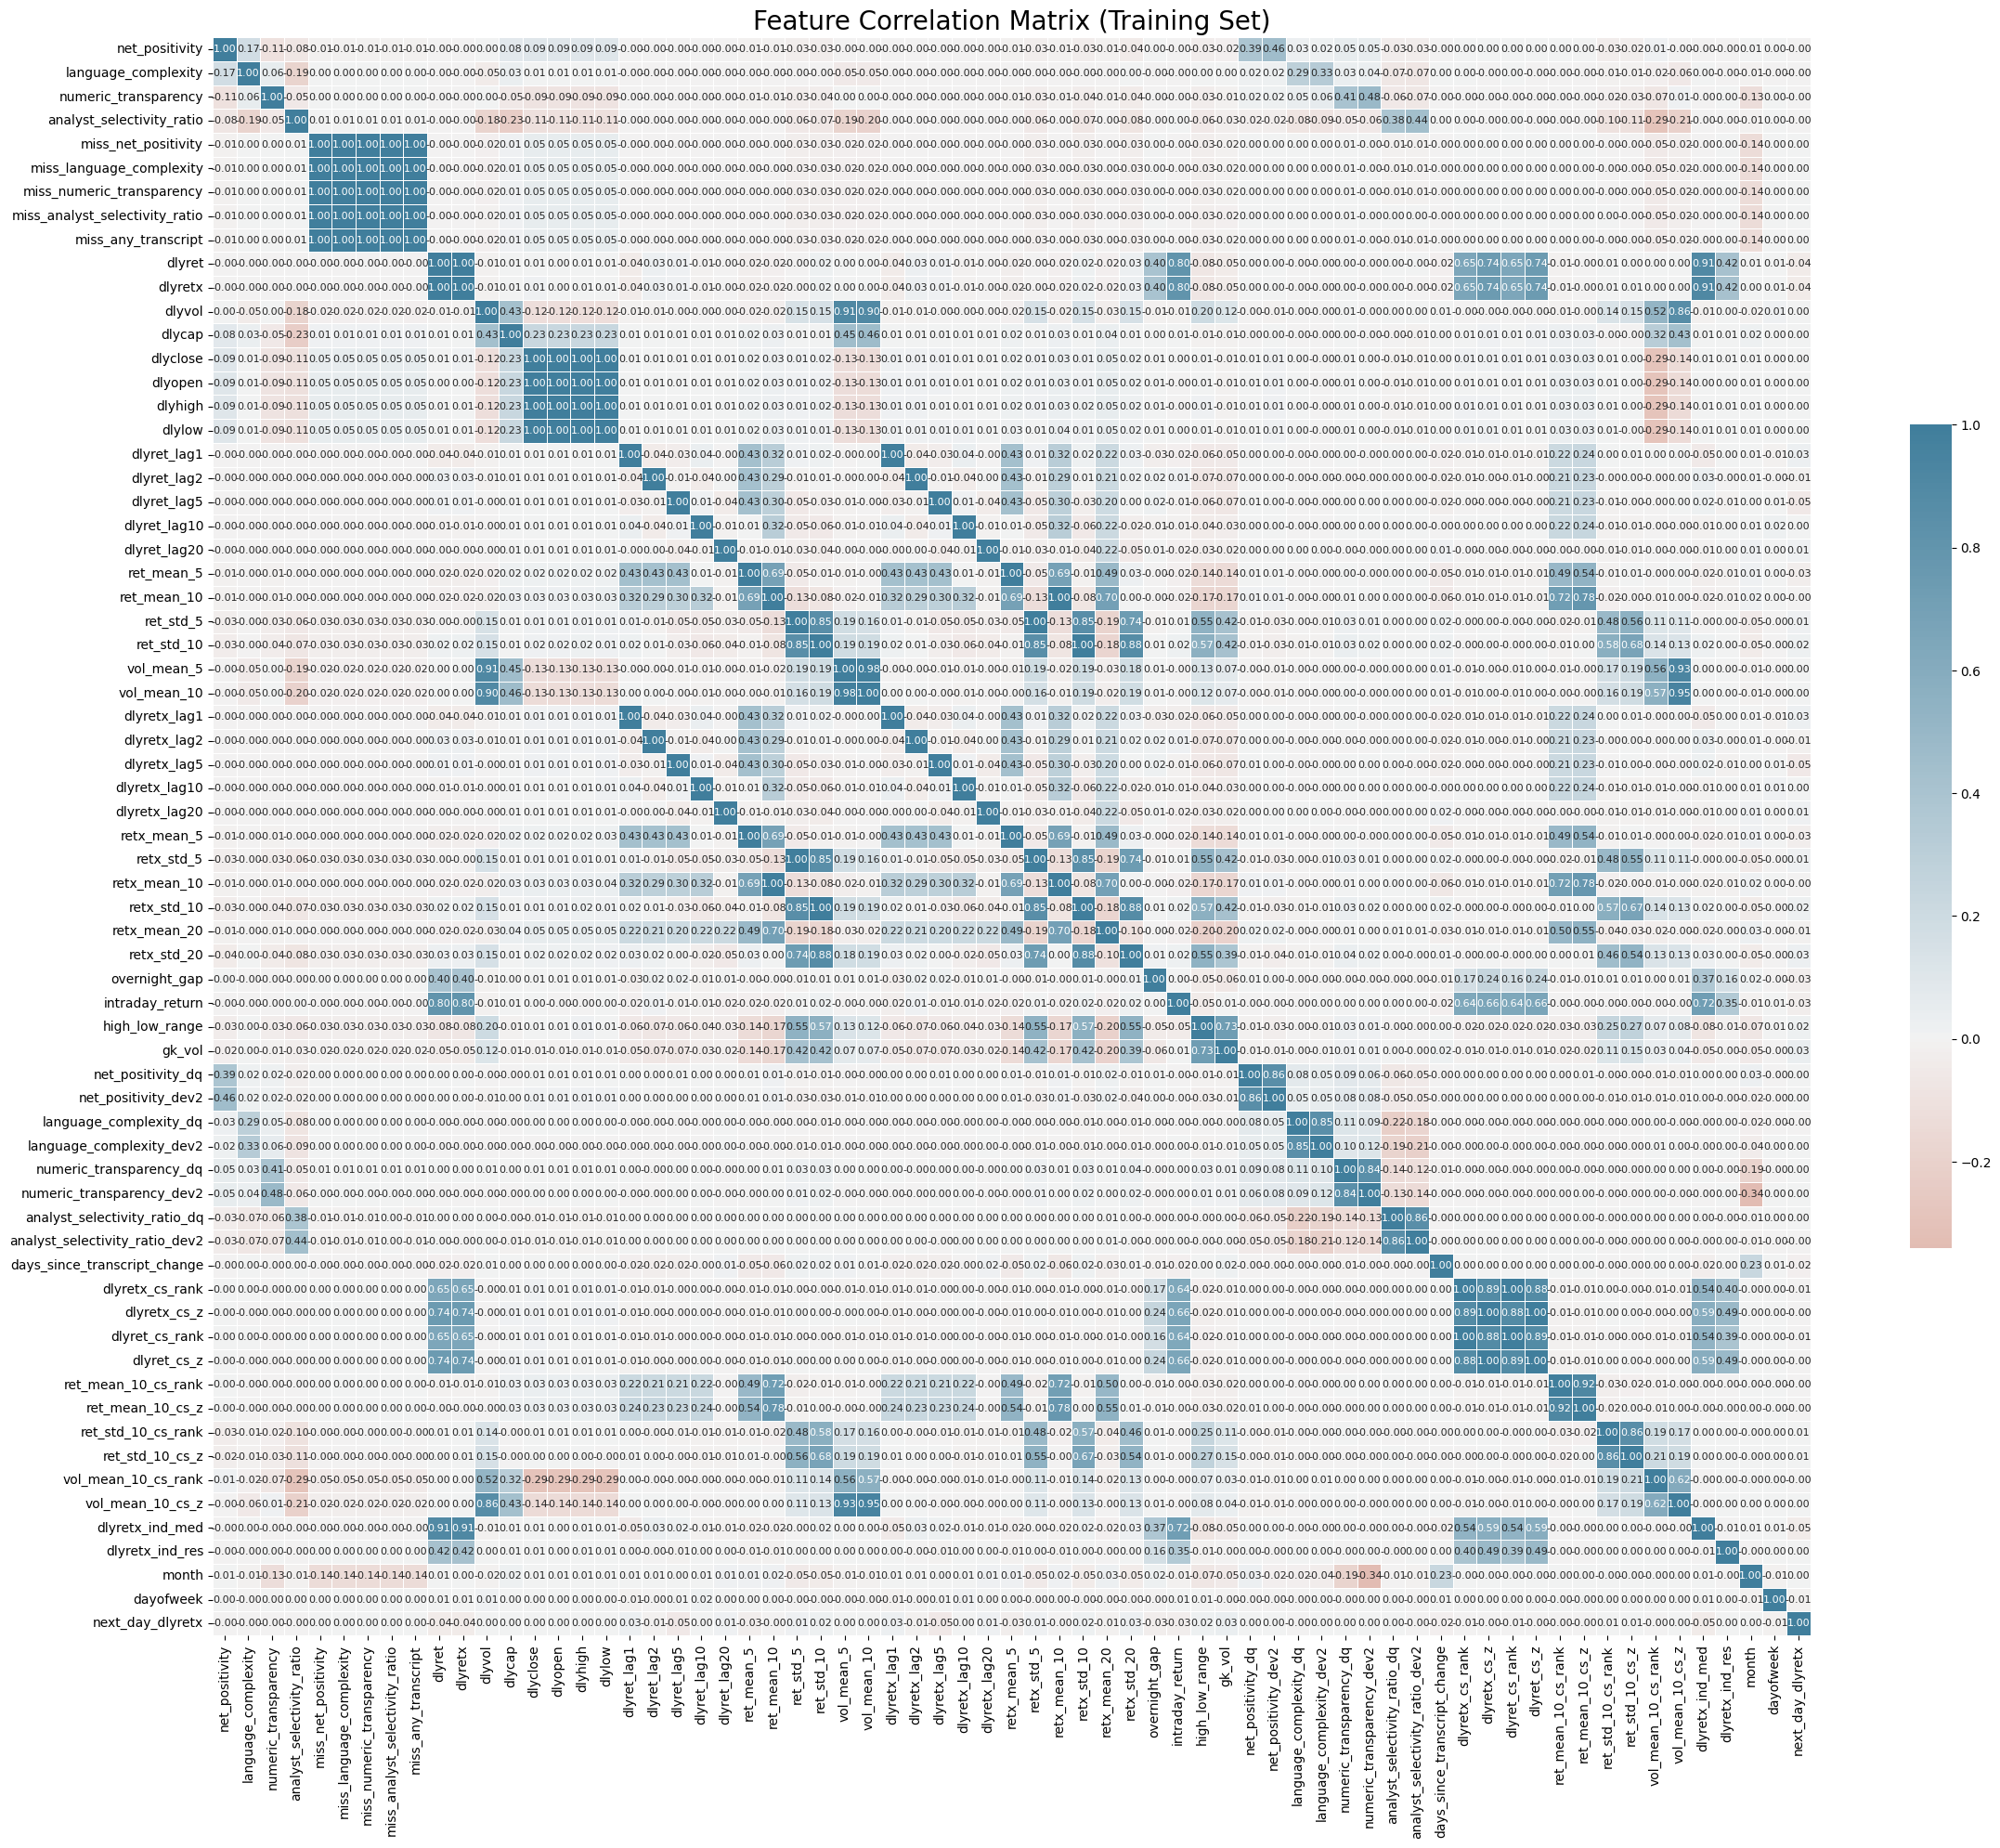


Feature Correlations with 'next_day_dlyretx':
--------------------------------------------------
gk_vol             0.031948
dlyretx_lag1       0.028319
dlyret_lag1        0.028188
retx_std_20        0.028098
ret_std_10         0.023562
                     ...   
dlyret            -0.042264
dlyretx           -0.042316
dlyretx_ind_med   -0.046709
dlyretx_lag5      -0.053448
dlyret_lag5       -0.053582
Name: next_day_dlyretx, Length: 66, dtype: float64


In [30]:
# --- Correlation heatmap of numeric features ---
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix on numeric features only
# (native categorical ID columns are intentionally excluded)
numeric_feature_cols = [c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(model_df[c])]
cols_to_correlate = numeric_feature_cols + [TARGET_COL]
correlation_matrix = model_df[cols_to_correlate].corr()

# 2. Plot the heatmap
plt.figure(figsize=(24, 20))

# Create a diverging colormap (blue for positive, red for negative)
cmap = sns.diverging_palette(20, 230, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    correlation_matrix, 
    cmap=cmap, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}, 
    annot=True,          # Show the actual correlation numbers
    fmt=".2f",           # Format to 2 decimal places
    annot_kws={"size": 8}
)

plt.title('Feature Correlation Matrix (Training Set)', fontsize=20)
plt.tight_layout()
plt.show()

# 3. Print out the correlations specifically with the target variable, sorted
target_corr = correlation_matrix[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
print(f"\nFeature Correlations with '{TARGET_COL}':")
print("-" * 50)
print(target_corr)


In [31]:
# ── Step 2: Time-based train / validation / test split ───────────────────────
TRAIN_END  = '2021-12-31'
VAL_START  = '2022-01-01'
VAL_END    = '2022-12-31'
TEST_START = '2023-01-01'

train_df = model_df[model_df['dlycaldt'] <= TRAIN_END].copy()
val_df   = model_df[(model_df['dlycaldt'] >= VAL_START) & (model_df['dlycaldt'] <= VAL_END)].copy()
test_df  = model_df[model_df['dlycaldt'] >= TEST_START].copy()

# Sanity checks — no overlap
assert train_df['dlycaldt'].max() < val_df['dlycaldt'].min(), 'Train/val overlap!'
assert val_df['dlycaldt'].max()   < test_df['dlycaldt'].min(), 'Val/test overlap!'

print(f"Train rows      : {len(train_df):>10,}  "
      f"({train_df['dlycaldt'].min().date()} → {train_df['dlycaldt'].max().date()})"," ",train_df.shape)
print(f"Validation rows : {len(val_df):>10,}  "
      f"({val_df['dlycaldt'].min().date()} → {val_df['dlycaldt'].max().date()})")
print(f"Test rows       : {len(test_df):>10,}  "
      f"({test_df['dlycaldt'].min().date()} → {test_df['dlycaldt'].max().date()})")

# Align native categorical identifiers from train levels (unseen val/test levels -> '__UNK__')
for col in ID_CAT_COLS:
    train_levels = pd.Index(train_df[col].dropna().astype(str).unique())
    if '__UNK__' not in train_levels:
        train_levels = train_levels.append(pd.Index(['__UNK__']))

    def _cast_with_levels(s):
        """Map IDs to train-only category levels; unseen val/test codes become __UNK__."""
        s = s.astype(str)
        s = s.where(s.isin(train_levels), '__UNK__')
        return pd.Categorical(s, categories=train_levels)

    train_df[col] = _cast_with_levels(train_df[col])
    val_df[col] = _cast_with_levels(val_df[col])
    test_df[col] = _cast_with_levels(test_df[col])

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]


Train rows      :    349,557  (2014-01-02 → 2021-12-31)   (349557, 82)
Validation rows :     44,318  (2022-01-03 → 2022-12-30)
Test rows       :     88,491  (2023-01-03 → 2024-12-30)


In [32]:
# ── Step 3: Evaluation helper ─────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr

def evaluate(y_true, y_pred, label=''):
    """Compute regression metrics and simple trading proxies; optionally print.

    Includes RMSE, MAE, R2, sign agreement (directional accuracy), and Spearman rank IC.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
    mae     = mean_absolute_error(y_true, y_pred)
    r2      = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true) == np.sign(y_pred))
    ic, _   = spearmanr(y_true, y_pred)

    result = dict(
        RMSE=rmse,
        MAE=mae,
        R2=r2,
        Directional_Accuracy=dir_acc,
        Spearman_IC=ic,
    )
    if label:
        print(f'\n── {label} ' + '─' * max(0, 50 - len(label)))
        for k, v in result.items():
            print(f'  {k:<25}: {v:.6f}')
    return result

# Container filled by model cells below
results = {}

print('evaluate() helper registered. results dict initialised.')


evaluate() helper registered. results dict initialised.


In [45]:
# ── Step 4a: LightGBM ────────────────────────────────────────────────────────
import lightgbm as lgb

# LightGBM handles NaNs natively and supports pandas category dtype
def _to_lgb(df):
    """Copy frame and cast ID_CAT_COLS to pandas Categorical for LightGBM native categories."""
    X = df.copy()
    for col in ID_CAT_COLS:
        X[col] = X[col].astype('category')
    return X

X_train_lgb = _to_lgb(X_train)
X_val_lgb   = _to_lgb(X_val)
X_test_lgb  = _to_lgb(X_test)

lgb_model = lgb.LGBMRegressor(
    n_estimators=237500,
    learning_rate=0.01,
    num_leaves=127,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    max_dept= 6,
    categorical_feature=ID_CAT_COLS,
    device = 'gpu',         # device='gpu' when USE_GPU=True and GPU build present
)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=200),
    ],
)

lgb_preds = lgb_model.predict(X_test_lgb)
results['LightGBM'] = evaluate(y_test, lgb_preds, label='LightGBM — Test set (2023-2024)')
print(f'\nBest iteration: {lgb_model.best_iteration_}')


h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2]	valid_0's l2: 0.000464699

── LightGBM — Test set (2023-2024) ───────────────────
  RMSE                     : 0.016410
  MAE                      : 0.011239
  R2                       : 0.000068
  Directional_Accuracy     : 0.521409
  Spearman_IC              : 0.013880

Best iteration: 2


In [44]:
# ── Step 4b: XGBoost ─────────────────────────────────────────────────────────
import xgboost as xgb

# Keep native categorical IDs on CPU; preserve GPU-safe fallback when needed.
def _to_xgb(df):
    """Prepare features for XGBoost.

    On CUDA, categoricals are integer-encoded (enable_categorical=False).
    On CPU, native categorical dtype is used (enable_categorical=True).

    Returns (X, enable_categorical).
    """
    X = df.copy()
    _xkw = globals().get('XGB_DEVICE_KWARGS', {})
    if _xkw.get('device') == 'cuda':
        for col in ID_CAT_COLS:
            X[col] = X[col].astype('category').cat.codes.astype('int32')
        return X, False
    for col in ID_CAT_COLS:
        X[col] = X[col].astype('category')
    return X, True

X_train_xgb, _enable_cat = _to_xgb(X_train)
X_val_xgb,   _           = _to_xgb(X_val)
X_test_xgb,  _           = _to_xgb(X_test)

_xgb_dev_kw = dict(globals().get('XGB_DEVICE_KWARGS') or {})
if not _xgb_dev_kw:
    _xgb_dev_kw = {'tree_method': 'hist'}

xgb_model = xgb.XGBRegressor(
    n_estimators=237500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=_enable_cat,
    early_stopping_rounds=100,
    random_state=42,
    verbosity=0,
    **_xgb_dev_kw,
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=200,
)

xgb_preds = xgb_model.predict(X_test_xgb)
results['XGBoost'] = evaluate(y_test, xgb_preds, label='XGBoost — Test set (2023-2024)')
print(f'\nBest iteration: {xgb_model.best_iteration}')


[0]	validation_0-rmse:0.02156
[151]	validation_0-rmse:0.02157

── XGBoost — Test set (2023-2024) ────────────────────
  RMSE                     : 0.016403
  MAE                      : 0.011237
  R2                       : 0.000964
  Directional_Accuracy     : 0.520629
  Spearman_IC              : 0.009452

Best iteration: 51


In [35]:
# ── Step 4c: Random Forest ───────────────────────────────────────────────────
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.impute import SimpleImputer

# # RF cannot handle NaN values — median-impute (fit on train, transform all splits)
# imputer = SimpleImputer(strategy='median')
# X_train_rf = imputer.fit_transform(X_train)
# X_val_rf   = imputer.transform(X_val)     # kept for reference; not used for early stopping
# X_test_rf  = imputer.transform(X_test)

# rf_model = RandomForestRegressor(
#     n_estimators=400,
#     max_depth=120,
#     min_samples_leaf=200,
#     n_jobs=-1,
#     random_state=42,
# )

# print('Training Random Forest (this may take a few minutes)...')
# rf_model.fit(X_train_rf, y_train)

# rf_preds = rf_model.predict(X_test_rf)
# results['RandomForest'] = evaluate(y_test, rf_preds, label='RandomForest — Test set (2023-2024)')
# print(f'\nn_estimators used: {rf_model.n_estimators}')

In [36]:
# ── GPU Setup ─────────────────────────────────────────────────────────────────
import subprocess, re
import numpy as np

def _probe_gpu():
    """Detect NVIDIA GPU via nvidia-smi subprocess; swallow errors and return False on failure."""
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
            timeout=10, stderr=subprocess.DEVNULL,
        ).decode().strip()
        if out:
            print(f'GPU detected : {out}')
            return True
    except Exception:
        pass
    print('No NVIDIA GPU detected via nvidia-smi — training on CPU.')
    return False

def _xgb_device_kwargs(use_gpu: bool) -> dict:
    """XGBoost device kwargs: CPU uses tree_method hist; GPU uses CUDA on 2.x else gpu_hist legacy."""
    import xgboost as _xgb
    ver = tuple(int(x) for x in re.match(r'(\d+)\.(\d+)', _xgb.__version__).groups())
    if not use_gpu:
        return {'tree_method': 'hist'}
    if ver >= (2, 0):
        print(f'XGBoost {_xgb.__version__}: device="cuda", tree_method="hist"')
        return {'tree_method': 'hist', 'device': 'cuda'}
    else:
        print(f'XGBoost {_xgb.__version__}: tree_method="gpu_hist" (legacy)')
        return {'tree_method': 'gpu_hist'}

def _lgb_device_kwarg(use_gpu: bool) -> dict:
    """LightGBM device dict; GPU path runs tiny training probes and falls back to CPU on failure."""
    if not use_gpu:
        return {}

    import lightgbm as _lgb

    # Try a tiny list-based probe first
    try:
        ds_list = _lgb.Dataset([[0, 0], [1, 1]], label=[0, 1])
        _lgb.train({'device': 'gpu', 'num_leaves': 4, 'verbose': -1}, ds_list, num_boost_round=1)
        print(f'LightGBM {_lgb.__version__}: GPU confirmed, using device="gpu"')
        return {'device': 'gpu'}
    except Exception:
        pass

    # Fallback probe using ndarray input
    try:
        X_np = np.array([[0.0, 0.0], [1.0, 1.0]], dtype=np.float32)
        y_np = np.array([0.0, 1.0], dtype=np.float32)
        ds_np = _lgb.Dataset(X_np, label=y_np)
        _lgb.train({'device': 'gpu', 'num_leaves': 4, 'verbose': -1}, ds_np, num_boost_round=1)
        print(f'LightGBM {_lgb.__version__}: GPU confirmed, using device="gpu"')
        return {'device': 'gpu'}
    except Exception as exc_np:
        print(f'LightGBM GPU unavailable ({exc_np}). Falling back to CPU.')
        return {}

USE_GPU           = _probe_gpu()
XGB_DEVICE_KWARGS = _xgb_device_kwargs(USE_GPU)
LGB_DEVICE_KWARG  = _lgb_device_kwarg(USE_GPU)

print(f'\nUSE_GPU={USE_GPU}  |  XGB kwargs={XGB_DEVICE_KWARGS}  |  LGB kwargs={LGB_DEVICE_KWARG}')


GPU detected : NVIDIA GeForce RTX 3050 Laptop GPU
XGBoost 3.2.0: device="cuda", tree_method="hist"
LightGBM 4.6.0: GPU confirmed, using device="gpu"

USE_GPU=True  |  XGB kwargs={'tree_method': 'hist', 'device': 'cuda'}  |  LGB kwargs={'device': 'gpu'}


In [37]:
# ── Tuning Setup: shared utilities ───────────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

# Walk-forward CV: expanding train windows by calendar date on train+val only (pre-test).
# Uses custom date-based folds below (not sklearn PredefinedSplit); d_trval must stay aligned with X, y rows.
TS_CV_N_FOLDS = 4
TS_CV_MIN_TRAIN_ROWS = 5_000


def _make_expanding_date_folds(d_trval, n_folds=TS_CV_N_FOLDS, min_train_rows=TS_CV_MIN_TRAIN_ROWS):
    """Expanding-window folds on ``dlycaldt`` (row-aligned with X, y).

    Unique calendar dates are split into ``n_folds + 1`` disjoint chronological segments.
    Fold ``k`` trains on segments ``0..k`` and validates on segment ``k+1``, so every
    validation date is strictly after every training date.
    """
    d = pd.to_datetime(d_trval).reset_index(drop=True)
    u = np.sort(d.unique())
    n_u = len(u)
    n_folds = int(min(max(2, n_folds), max(2, n_u - 1)))
    parts = np.array_split(u, n_folds + 1)
    folds = []
    for k in range(n_folds):
        train_dates = np.unique(np.concatenate(parts[: k + 1]))
        val_dates = parts[k + 1]
        if len(val_dates) == 0:
            continue
        tr_m = d.isin(train_dates).to_numpy()
        va_m = d.isin(val_dates).to_numpy()
        tr_idx = np.flatnonzero(tr_m)
        va_idx = np.flatnonzero(va_m)
        if len(tr_idx) < min_train_rows or len(va_idx) == 0:
            continue
        assert d.iloc[tr_idx].max() < d.iloc[va_idx].min(), f'TS-CV fold {k}: train max date >= val min date'
        folds.append((tr_idx, va_idx))
    return folds


def _summarize_ts_folds(d_trval, folds, name='TS-CV'):
    """Print fold date ranges for walk-forward CV (diagnostic)."""
    d = pd.to_datetime(d_trval).reset_index(drop=True)
    print(f'\n── {name}: time-series folds (expanding by date) ' + '─' * 12)
    for i, (tr_idx, va_idx) in enumerate(folds):
        d_tr, d_va = d.iloc[tr_idx], d.iloc[va_idx]
        print(
            f'  Fold {i + 1}: train {len(tr_idx):,} rows  '
            f'({d_tr.min().date()} → {d_tr.max().date()})  |  '
            f'val {len(va_idx):,} rows  ({d_va.min().date()} → {d_va.max().date()})'
        )


def _rmse(y_true, y_pred):
    """Root mean squared error as float."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def _run_ts_param_search(estimator, param_grid, X, y, d_trval, name, backend='sklearn'):
    """Walk-forward CV over ParameterGrid using expanding date folds.

    backend 'lgb': early stopping on each fold val set.
    backend 'xgb': eval_set early stopping where supported.
    backend 'sklearn': plain fit on fold train only.

    Returns (None, best_params, best_mean_rmse) for compatibility with downstream refit cells.
    """
    folds = _make_expanding_date_folds(d_trval, n_folds=TS_CV_N_FOLDS, min_train_rows=TS_CV_MIN_TRAIN_ROWS)
    if not folds:
        raise ValueError('No valid time-series folds. Lower TS_CV_MIN_TRAIN_ROWS or TS_CV_N_FOLDS.')

    d_series = pd.to_datetime(d_trval).reset_index(drop=True)
    _summarize_ts_folds(d_series, folds, name=name)

    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    best_mean = np.inf
    best_params_out = None
    leaderboard = []
    grid = list(ParameterGrid(param_grid))

    print(f'\n── {name}: {len(grid)} hyperparameter combos × {len(folds)} folds ' + '─' * 8)

    for j, params in enumerate(grid):
        fold_rmses = []
        for tr_idx, va_idx in folds:
            X_tr = X.iloc[tr_idx]
            X_va = X.iloc[va_idx]
            y_tr = y.iloc[tr_idx]
            y_va = y.iloc[va_idx]
            est = clone(estimator).set_params(**params)

            if backend == 'lgb':
                import lightgbm as _lgb_mod
                est.fit(
                    X_tr,
                    y_tr,
                    eval_set=[(X_va, y_va)],
                    callbacks=[_lgb_mod.early_stopping(stopping_rounds=100, verbose=False)],
                )
            elif backend == 'xgb':
                est.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
            else:
                est.fit(X_tr, y_tr)

            pred = est.predict(X_va)
            fold_rmses.append(_rmse(y_va, pred))

        mean_rmse = float(np.mean(fold_rmses))
        leaderboard.append({'params': str(params), 'mean_rmse': mean_rmse, 'fold_rmse': tuple(fold_rmses)})
        print(f'  [{j + 1}/{len(grid)}] mean_val_RMSE={mean_rmse:.6f}  params={params}')

        if mean_rmse < best_mean:
            best_mean = mean_rmse
            best_params_out = dict(params)

    print(f'\nBest params ({name}): {best_params_out}')
    print(f'Best mean CV RMSE (across folds): {best_mean:.6f}')

    cv_df = pd.DataFrame(leaderboard).sort_values('mean_rmse')
    print(cv_df.head(min(12, len(cv_df))).to_string(index=False))

    return None, best_params_out, best_mean


# Ensure helper transforms exist before tuning cells run.
# Step 4a/4b define these later as well, but tuning runs earlier.
if '_to_lgb' not in globals():
    def _to_lgb(df):
        """Fallback: categorical cast if Step 4a has not defined _to_lgb yet."""
        X = df.copy()
        for col in ID_CAT_COLS:
            X[col] = X[col].astype('category')
        return X

if '_to_xgb' not in globals():
    def _to_xgb(df):
        """Fallback: match Step 4b CUDA vs CPU categorical handling if not yet defined."""
        X = df.copy()
        _xkw = globals().get('XGB_DEVICE_KWARGS', {})
        if _xkw.get('device') == 'cuda':
            for col in ID_CAT_COLS:
                X[col] = X[col].astype('category').cat.codes.astype('int32')
            return X, False
        for col in ID_CAT_COLS:
            X[col] = X[col].astype('category')
        return X, True

# Train+val rows for walk-forward CV (test period excluded). dlycaldt aligns rows to calendar folds.
_trval_df = pd.concat([train_df, val_df], ignore_index=True)
X_trval = _trval_df[FEATURE_COLS]
y_trval = _trval_df[TARGET_COL]
d_trval = _trval_df['dlycaldt']

assert pd.to_datetime(d_trval).max() < test_df['dlycaldt'].min(), 'TS-CV must exclude test period'

# Storage for best params (populated by tuning cells below)
best_params_lgb = {}
best_params_xgb = {}
best_params_rf = {}

print(f'X_trval shape : {X_trval.shape}  (train={len(train_df):,} + val={len(val_df):,})')
print('Tuning utilities ready (walk-forward CV by `dlycaldt`).')



X_trval shape : (393875, 69)  (train=349,557 + val=44,318)
Tuning utilities ready (walk-forward CV by `dlycaldt`).


In [38]:
# ── Tuning Cell B: LightGBM (time-series CV) ─────────────────────────────────
import lightgbm as lgb

# Apply the same category-dtype cast used in Step 4a
X_trval_lgb = _to_lgb(X_trval)

lgb_base = lgb.LGBMRegressor(
    n_estimators=1500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    device='gpu',
    categorical_feature=ID_CAT_COLS,
)

lgb_param_grid = {
    'num_leaves':        [63],#[63, 127, 255],
    'min_child_samples': [20],#[20, 100],
    'learning_rate':     [0.05],#[0.01, 0.05],
}
# 3 × 2 × 2 = 12 combos

_, best_params_lgb, _ = _run_ts_param_search(
    lgb_base, lgb_param_grid, X_trval_lgb, y_trval, d_trval, 'LightGBM', backend='lgb'
)



── LightGBM: time-series folds (expanding by date) ────────────
  Fold 1: train 78,160 rows  (2014-01-02 → 2015-10-20)  |  val 77,844 rows  (2015-10-21 → 2017-08-08)
  Fold 2: train 156,004 rows  (2014-01-02 → 2017-08-08)  |  val 78,656 rows  (2017-08-09 → 2019-05-29)
  Fold 3: train 234,660 rows  (2014-01-02 → 2019-05-29)  |  val 79,484 rows  (2019-05-30 → 2021-03-16)
  Fold 4: train 314,144 rows  (2014-01-02 → 2021-03-16)  |  val 79,731 rows  (2021-03-17 → 2022-12-30)

── LightGBM: 1 hyperparameter combos × 4 folds ────────


h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
h:\My Drive\Project\FA Project\.venv\Lib\site-pa

  [1/1] mean_val_RMSE=0.019020  params={'learning_rate': 0.05, 'min_child_samples': 20, 'num_leaves': 63}

Best params (LightGBM): {'learning_rate': 0.05, 'min_child_samples': 20, 'num_leaves': 63}
Best mean CV RMSE (across folds): 0.019020
                                                            params  mean_rmse                                                                              fold_rmse
{'learning_rate': 0.05, 'min_child_samples': 20, 'num_leaves': 63}    0.01902 (0.01445157765801782, 0.01547962292475227, 0.027025720875408363, 0.019121178333054614)


In [ ]:
# ── Tuning Cell C: XGBoost (time-series CV) ─────────────────────────────────
import xgboost as xgb

# _to_xgb returns (X, enable_categorical_flag); reuse the GPU-aware cast from Step 4b
X_trval_xgb, _enable_cat_tune = _to_xgb(X_trval)

xgb_base = xgb.XGBRegressor(
    n_estimators=15000,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=_enable_cat_tune,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=100,
    **(globals().get('XGB_DEVICE_KWARGS') or {'tree_method': 'hist'}),
)

xgb_param_grid = {
    'max_depth':       [4, 6, 8],
    'min_child_weight':[1, 5],
    'learning_rate':   [0.01, 0.05],
}
# 3 × 2 × 2 = 12 combos

_, best_params_xgb, _ = _run_ts_param_search(
    xgb_base, xgb_param_grid, X_trval_xgb, y_trval, d_trval, 'XGBoost', backend='xgb'
)



── XGBoost: time-series folds (expanding by date) ────────────
  Fold 1: train 78,160 rows  (2014-01-02 → 2015-10-20)  |  val 77,844 rows  (2015-10-21 → 2017-08-08)
  Fold 2: train 156,004 rows  (2014-01-02 → 2017-08-08)  |  val 78,656 rows  (2017-08-09 → 2019-05-29)
  Fold 3: train 234,660 rows  (2014-01-02 → 2019-05-29)  |  val 79,484 rows  (2019-05-30 → 2021-03-16)
  Fold 4: train 314,144 rows  (2014-01-02 → 2021-03-16)  |  val 79,731 rows  (2021-03-17 → 2022-12-30)

── XGBoost: 12 hyperparameter combos × 4 folds ────────
  [1/12] mean_val_RMSE=0.019018  params={'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 1}
  [2/12] mean_val_RMSE=0.019018  params={'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 5}
  [3/12] mean_val_RMSE=0.019018  params={'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 1}
  [4/12] mean_val_RMSE=0.019018  params={'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 5}
  [5/12] mean_val_RMSE=0.019017  params={'learning_rate'

In [40]:
# # ── Tuning Cell D: RandomForest (time-series CV; commented) ─────────────────
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.impute import SimpleImputer

# # Impute on train only, transform val to prevent leakage
# _tune_imputer = SimpleImputer(strategy='median')
# X_trval_rf = _tune_imputer.fit_transform(X_trval)   # if enabled: impute per TS-CV train fold only (avoid leakage)

# # Correct: refit imputer on train portion only, then transform val portion
# _tune_imputer_tr = SimpleImputer(strategy='median')
# _X_trval_train_imp = _tune_imputer_tr.fit_transform(X_trval.iloc[:len(X_train)])
# _X_trval_val_imp   = _tune_imputer_tr.transform(X_trval.iloc[len(X_train):])
# import numpy as np
# X_trval_rf = np.vstack([_X_trval_train_imp, _X_trval_val_imp])

# rf_base = RandomForestRegressor(
#     random_state=42,
#     n_jobs=-1,
# )

# rf_param_grid = {
#     'n_estimators':    [200, 400],
#     'max_depth':       [None, 30, 60],
#     'min_samples_leaf':[50, 200],
# }
# # 2 × 3 × 2 = 12 combos

# _, best_params_rf, _ = _run_ts_param_search(rf_base, rf_param_grid, X_trval_rf, y_trval, d_trval, 'RandomForest', backend='sklearn')


In [41]:
# ── Tuning Cell E: Refit on train+val → evaluate on test ─────────────────────
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
import numpy as np

# ── 1. LightGBM tuned refit ───────────────────────────────────────────────────
X_trval_lgb_refit = _to_lgb(X_trval)
X_test_lgb_refit  = _to_lgb(X_test)

lgb_tuned = lgb.LGBMRegressor(
    n_estimators=1500,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
    categorical_feature=ID_CAT_COLS,
    **LGB_DEVICE_KWARG,
    **best_params_lgb,   # num_leaves, min_child_samples, learning_rate from grid
)
lgb_tuned.fit(X_trval_lgb_refit, y_trval)
lgb_tuned_preds = lgb_tuned.predict(X_test_lgb_refit)
results['LightGBM_tuned'] = evaluate(y_test, lgb_tuned_preds, label='LightGBM tuned — Test set (2023-2024)')

# ── 2. XGBoost tuned refit ────────────────────────────────────────────────────
X_trval_xgb_refit, _ec = _to_xgb(X_trval)
X_test_xgb_refit,  _   = _to_xgb(X_test)

xgb_tuned = xgb.XGBRegressor(
    n_estimators=1500,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=_ec,
    random_state=42,
    verbosity=0,
    **(globals().get('XGB_DEVICE_KWARGS') or {'tree_method': 'hist'}),
    **best_params_xgb,   # max_depth, min_child_weight, learning_rate from grid
)
xgb_tuned.fit(X_trval_xgb_refit, y_trval)
xgb_tuned_preds = xgb_tuned.predict(X_test_xgb_refit)
results['XGBoost_tuned'] = evaluate(y_test, xgb_tuned_preds, label='XGBoost tuned — Test set (2023-2024)')

# ── 3. RandomForest tuned refit ───────────────────────────────────────────────
# Impute: fit on train, transform val, combine for refit; transform test separately
# _rf_imp = SimpleImputer(strategy='median')
# _X_tr_imp  = _rf_imp.fit_transform(X_train)
# _X_val_imp = _rf_imp.transform(X_val)
# _X_te_imp  = _rf_imp.transform(X_test)
# X_trval_rf_refit = np.vstack([_X_tr_imp, _X_val_imp])

# rf_tuned = RandomForestRegressor(
#     random_state=42,
#     n_jobs=-1,
#     **best_params_rf,    # n_estimators, max_depth, min_samples_leaf from grid
# )
# rf_tuned.fit(X_trval_rf_refit, y_trval)
# rf_tuned_preds = rf_tuned.predict(_X_te_imp)
# results['RandomForest_tuned'] = evaluate(y_test, rf_tuned_preds, label='RandomForest tuned — Test set (2023-2024)')

# ── Summary comparison ────────────────────────────────────────────────────────
import pandas as pd
print('\n\n══ Model comparison: baseline vs tuned ══')
compare_df = pd.DataFrame(results).T[['RMSE', 'MAE', 'R2', 'Directional_Accuracy', 'Spearman_IC']]
print(compare_df.to_string())


h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
h:\My Drive\Project\FA Project\.venv\Lib\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")



── LightGBM tuned — Test set (2023-2024) ─────────────
  RMSE                     : 0.016702
  MAE                      : 0.011536
  R2                       : -0.035830
  Directional_Accuracy     : 0.497497
  Spearman_IC              : 0.006615

── XGBoost tuned — Test set (2023-2024) ──────────────
  RMSE                     : 0.016613
  MAE                      : 0.011423
  R2                       : -0.024744
  Directional_Accuracy     : 0.502413
  Spearman_IC              : -0.000745


══ Model comparison: baseline vs tuned ══
                    RMSE       MAE        R2  Directional_Accuracy  Spearman_IC
LightGBM        0.016410  0.011239  0.000068              0.521409     0.013881
XGBoost         0.016405  0.011237  0.000692              0.521782     0.005388
LightGBM_tuned  0.016702  0.011536 -0.035830              0.497497     0.006615
XGBoost_tuned   0.016613  0.011423 -0.024744              0.502413    -0.000745


In [42]:
# # ── Step 5: Model comparison table + feature importance plots ─────────────────
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # ── Results table ─────────────────────────────────────────────────────────────
# results_df = pd.DataFrame(results).T
# results_df = results_df[['RMSE', 'MAE', 'R2', 'Directional_Accuracy', 'Spearman_IC']]
# results_df = results_df.sort_values('Spearman_IC', ascending=False)

# print('══ Model comparison on test set (2023-2024) ══')
# print(results_df.round(6).to_string())

# best_model = results_df.index[0]
# best_ic    = results_df.loc[best_model, 'Spearman_IC']
# print(f'\nBest model by Spearman IC: {best_model}  (IC = {best_ic:.6f})')

# # ── Feature importance helper ──────────────────────────────────────────────────
# def plot_importance(importances, feature_names, title, top_n=20, ax=None):
#     importances = np.asarray(importances, dtype=float)
#     idx = np.argsort(importances)[-top_n:]
#     names = np.array(feature_names)[idx]
#     vals  = importances[idx]
#     ax.barh(names, vals)
#     ax.set_title(title, fontsize=11)
#     ax.set_xlabel('Importance')

# fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# # LightGBM — gain importance
# lgb_imp = lgb_model.booster_.feature_importance(importance_type='gain')
# plot_importance(lgb_imp, FEATURE_COLS, 'LightGBM — Feature Importance (gain)', ax=axes[0])

# # XGBoost — total gain importance
# xgb_imp = xgb_model.feature_importances_
# plot_importance(xgb_imp, FEATURE_COLS, 'XGBoost — Feature Importance (total gain)', ax=axes[1])

# # Random Forest
# # rf_imp = rf_model.feature_importances_
# # plot_importance(rf_imp, FEATURE_COLS, 'RandomForest — Feature Importance (mean impurity decrease)', ax=axes[2])

# plt.suptitle('Top-20 Feature Importances by Model  |  Test set 2023-2024', fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()

══ Model comparison on test set (2023-2024) ══
                    RMSE       MAE        R2  Directional_Accuracy  Spearman_IC
LightGBM        0.016410  0.011239  0.000068              0.521409     0.013881
LightGBM_tuned  0.016702  0.011536 -0.035830              0.497497     0.006615
XGBoost         0.016405  0.011237  0.000692              0.521782     0.005388
XGBoost_tuned   0.016613  0.011423 -0.024744              0.502413    -0.000745

Best model by Spearman IC: LightGBM  (IC = 0.013881)


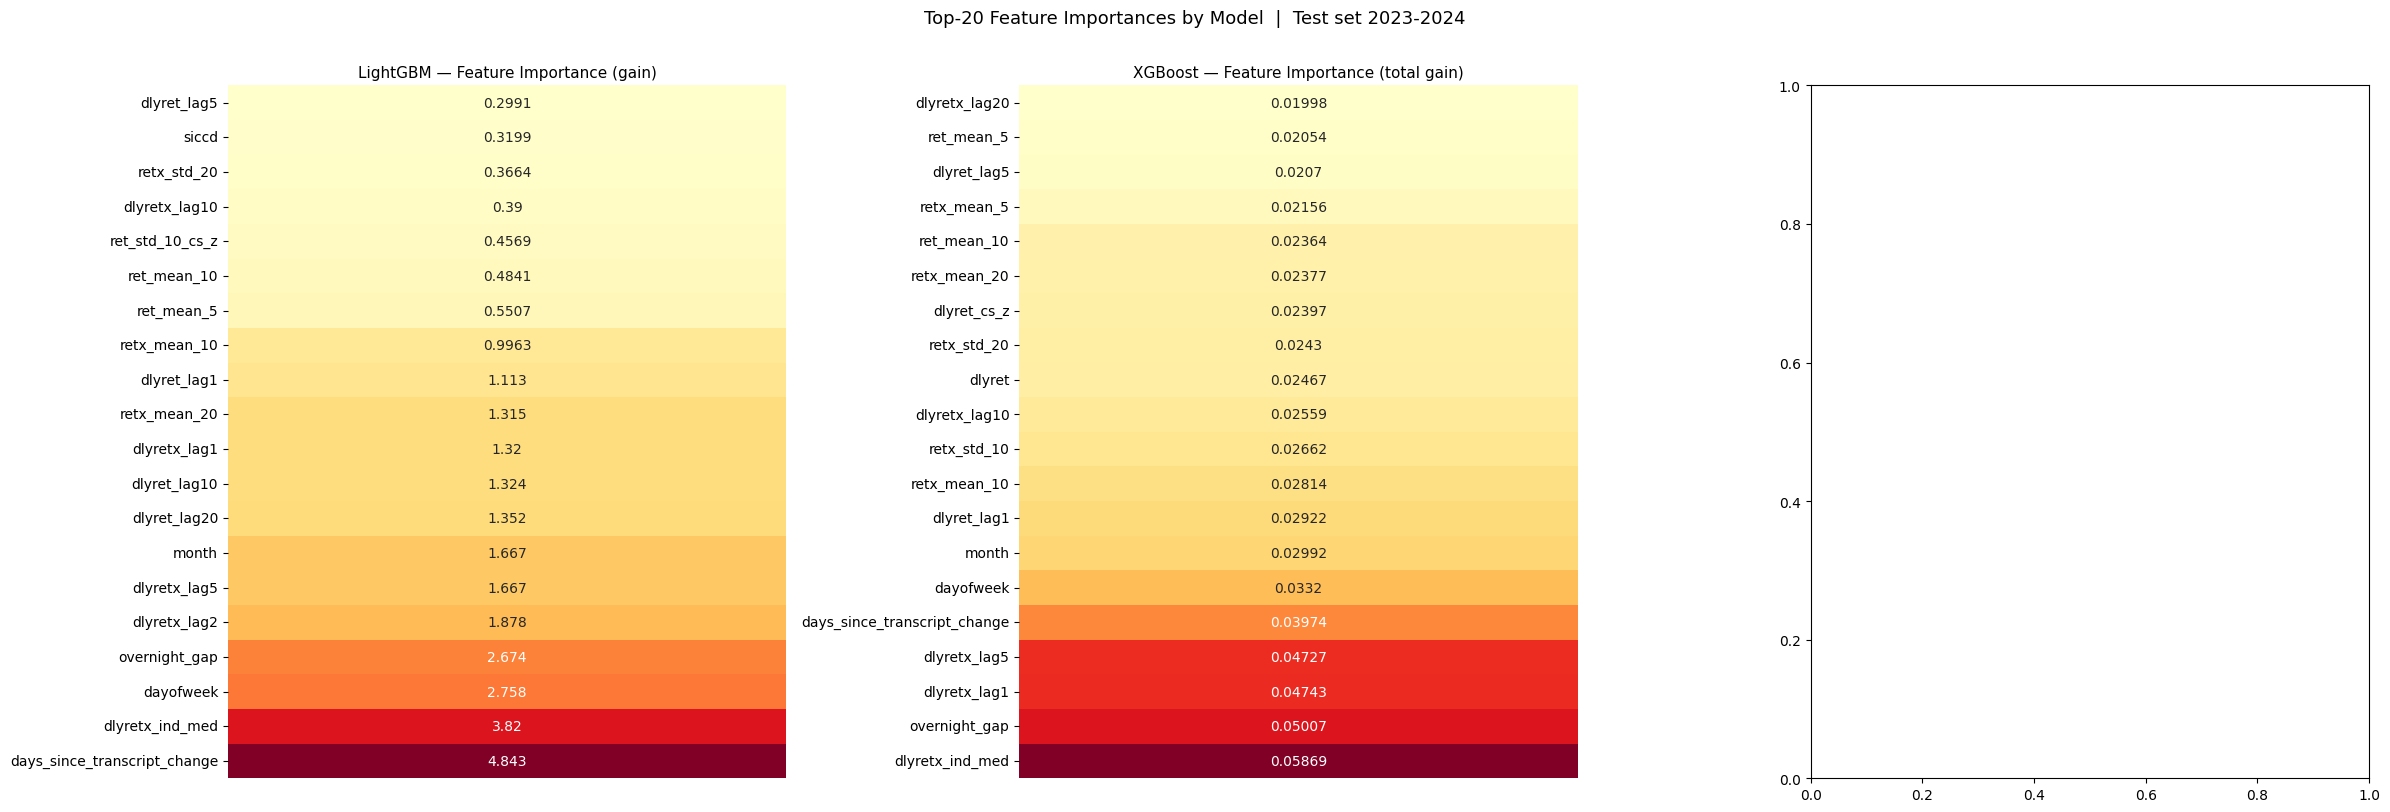

In [43]:
# ── Step 5: Model comparison table + feature importance plots ─────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Results table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T
results_df = results_df[['RMSE', 'MAE', 'R2', 'Directional_Accuracy', 'Spearman_IC']]
results_df = results_df.sort_values('Spearman_IC', ascending=False)

print('══ Model comparison on test set (2023-2024) ══')
print(results_df.round(6).to_string())

best_model = results_df.index[0]
best_ic    = results_df.loc[best_model, 'Spearman_IC']
print(f'\nBest model by Spearman IC: {best_model}  (IC = {best_ic:.6f})')

# ── Feature importance helper ──────────────────────────────────────────────────
def plot_importance(importances, feature_names, title, top_n=20, ax=None):
    """Plot top-N feature importances as a horizontal heatmap row (uses seaborn)."""
    importances = np.asarray(importances, dtype=float)
    idx = np.argsort(importances)[-top_n:]
    names = np.array(feature_names)[idx]
    vals  = importances[idx]
    
    # Reshape values to Nx1 array for heatmap
    vals_2d = vals.reshape(-1, 1)
    
    # Plot as a heatmap
    sns.heatmap(vals_2d, annot=True, fmt=".4g", cmap="YlOrRd", ax=ax, cbar=False,
                yticklabels=names, xticklabels=False)
    
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# LightGBM — gain importance
lgb_imp = lgb_model.booster_.feature_importance(importance_type='gain')
plot_importance(lgb_imp, FEATURE_COLS, 'LightGBM — Feature Importance (gain)', ax=axes[0])

# XGBoost — total gain importance
xgb_imp = xgb_model.feature_importances_
plot_importance(xgb_imp, FEATURE_COLS, 'XGBoost — Feature Importance (total gain)', ax=axes[1])

# Random Forest
# rf_imp = rf_model.feature_importances_
# plot_importance(rf_imp, FEATURE_COLS, 'RandomForest — Feature Importance (mean impurity decrease)', ax=axes[2])

plt.suptitle('Top-20 Feature Importances by Model  |  Test set 2023-2024', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
